# End-to-End Sales Profit Prediction
## XGBoost vs Extra Trees — Professional Machine Learning Project

**Dataset:** `cleaned_sales_data_with_days.xlsx`  
**Problem type:** Supervised regression  
**Primary target:** `Profit` (order-level profit, TL)  
**Models:** XGBoost and Extra Trees  
**Validation:** Chronological split + `TimeSeriesSplit`

This notebook is a full ML lifecycle: problem definition, data audit, leakage control, feature engineering, leakage-safe pipelines, baseline, tuned tree models, explainability, error analysis, and a business-facing conclusion.

> All metrics in the final report are computed from models trained in this notebook. Nothing is hard-coded in advance.

# 1. Project Overview

The file is a cleaned transactional sales table (one row = one order). Columns mix operational attributes (product, city, channel, quantity, price, discount) with accounting fields that are **derived after the sale**.

The business question this project answers:

> Given information that would be known when an order is placed **without using unit cost or post-sale accounting totals**, how well can we estimate order profit (`Profit`)?

That framing is intentional. If unit cost and the derived totals are kept, `Profit` is an arithmetic identity, not a learning problem. The leakage section demonstrates this identity, then removes those columns from the feature set.

# 2. Business / ML Problem Definition

| Item | Decision |
|------|----------|
| Task | Regression |
| Target | `Profit` |
| Unit of prediction | Single order |
| Decision use-case | Estimate expected profit from commercial order attributes (what, where, who, how many, list price, discount, when) |
| Primary metric | MAE (TL) — robust to the heavy right tail of profit |
| Secondary metrics | RMSE, R², Median AE, sMAPE |
| Why not MAPE as primary | `Profit` has negative values (losses) and small-magnitude orders; percentage errors become unstable |
| Split | Chronological (past → train, future → test). Random split would leak the future |

**Target choice (not an assumption):** `Profit` is the business KPI already used in the statistical analysis of this dataset. `Net_Sales` is also derived (`Quantity × Unit_Price_TL × (1 − Discount_Rate)`), so predicting it with those three columns would also be trivial. Profit is the more informative remaining target **after** dropping the identity inputs that would make it trivial.

If `Profit` had been absent, the fallback target would have been `Net_Sales` with quantity/price/discount removed — a different (demand) problem.

# 3. Imports and Configuration

In [1]:
from __future__ import annotations

import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_TRIALS = 20
IQR_K = 1.5
DATA_PATH = Path("cleaned_sales_data_with_days.xlsx")
TARGET = "Profit"

np.random.seed(RANDOM_STATE)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.unicode_minus": False,
        "font.family": "DejaVu Sans",
    }
)
sns.set_theme(style="whitegrid", context="notebook")

PRIMARY = "#2F5D8A"
ACCENT = "#C0392B"
SECOND = "#1E8449"
MUTED = "#7F8C8D"

RESULTS = {}

In [2]:
def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    medae = float(np.median(np.abs(y_true - y_pred)))
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0.0, 1.0, denom)
    smape = float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))
    # MAPE is reported only as a diagnostic; unstable near zero / for losses.
    mape_mask = np.abs(y_true) > 1.0
    mape = (
        float(np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100.0)
        if mape_mask.any()
        else np.nan
    )
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MedianAE": medae,
        "sMAPE": smape,
        "MAPE_gt1": mape,
    }


def metrics_frame(named: dict[str, dict]) -> pd.DataFrame:
    return pd.DataFrame(named).T.round(4)


def iqr_bounds(series: pd.Series, k: float = IQR_K):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr, iqr


def chronological_masks(dates: pd.Series, test_size: float = TEST_SIZE):
    unique_dates = np.sort(pd.to_datetime(dates).unique())
    n_test = max(1, int(math.ceil(len(unique_dates) * test_size)))
    cutoff = unique_dates[-n_test]
    train_mask = pd.to_datetime(dates) < cutoff
    test_mask = ~train_mask
    return train_mask, test_mask, pd.Timestamp(cutoff)


def add_rowwise_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    ts = pd.to_datetime(out["Date"])
    out["year"] = ts.dt.year.astype(int)
    out["month"] = ts.dt.month.astype(int)
    out["day"] = ts.dt.day.astype(int)
    out["day_of_week"] = ts.dt.dayofweek.astype(int)
    out["week_of_year"] = ts.dt.isocalendar().week.astype(int)
    out["quarter"] = ts.dt.quarter.astype(int)
    out["is_weekend"] = (ts.dt.dayofweek >= 5).astype(int)
    out["is_month_start"] = ts.dt.is_month_start.astype(int)
    out["is_month_end"] = ts.dt.is_month_end.astype(int)
    out["net_unit_price"] = out["Unit_Price_TL"] * (1.0 - out["Discount_Rate"])
    out["list_revenue"] = out["Quantity"] * out["Unit_Price_TL"]
    out["discount_value_unit"] = out["Unit_Price_TL"] * out["Discount_Rate"]
    return out


def annotate(text: str):
    display(Markdown(text))

**Why these constants?**

- `RANDOM_STATE = 42` makes tree randomness, Optuna sampling, SHAP subsampling and permutation repeats reproducible.
- `TEST_SIZE = 0.20` holds out the most recent 20% of **calendar dates** (not shuffled rows).
- `CV_FOLDS = 5` is the expanding-window `TimeSeriesSplit` inside the training period.
- `N_TRIALS = 20` is a bounded Optuna budget: large enough to beat defaults, small enough that the notebook stays runnable.

# 4. Data Loading

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.name} (place it in the same folder as this notebook)")

df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()

print(f"Loaded: {DATA_PATH.name}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Loaded: cleaned_sales_data_with_days.xlsx
Shape: 958 rows x 18 columns


,Order_ID,Date,Day_Type,City,Region,Product,Category,Sales_Channel,Customer_Type,Quantity,Unit_Price_TL,Discount_Rate,Unit_Cost_TL,Payment_Method,Net_Sales,Total_Cost,Profit,Profit_Margin
0,SP00002,2026-03-01,Weekend,Bursa,Marmara,Desk Lamp,Office Accessories,Store,SME,4,878.54,0.00,509.70,Bank Transfer,3514.16,2038.80,1475.36,0.419833
1,SP00001,2026-06-13,Weekend,Istanbul,Marmara,Wireless Mouse,Electronics,Online,Individual,5,534.70,0.00,314.44,Credit Card,2673.50,1572.20,1101.30,0.411932
2,SP00005,2026-03-16,Weekday,Konya,Central Anatolia,Wireless Mouse,Electronics,Dealer,Individual,2,547.80,0.05,290.37,Bank Transfer,1040.82,580.74,460.08,0.442036
3,SP00004,2026-05-18,Weekday,Trabzon,Black Sea,Wireless Mouse,Electronics,Online,Individual,6,529.86,0.10,313.44,Credit Card,2861.24,1880.64,980.60,0.342719
4,SP00008,2026-06-14,Weekend,Istanbul,Marmara,Office Chair,Furniture,Online,SME,3,6029.23,0.10,4187.94,Credit Card,16278.92,12563.82,3715.10,0.228215
5,SP00006,2026-01-19,Weekday,Bursa,Marmara,Notebook Set,Stationery,Store,Individual,2,173.37,0.10,89.40,Bank Transfer,312.07,178.80,133.27,0.427044
6,SP00003,2026-04-19,Weekend,Istanbul,Marmara,Monitor 27,Electronics,Online,SME,1,5982.81,0.05,4848.49,Bank Transfer,5683.67,4848.49,835.18,0.146944
7,SP00011,2026-01-01,Weekday,Konya,Central Anatolia,Backpack,Accessories,Online,Individual,1,1332.53,0.00,794.78,Credit Card,1332.53,794.78,537.75,0.403556
8,SP00522,2026-02-01,Weekend,Ankara,Central Anatolia,Laptop Stand,Office Accessories,Online,Individual,2,631.30,0.15,389.69,Credit Card,1073.21,779.38,293.83,0.273786
9,SP00540,2026-02-01,Weekend,Istanbul,Marmara,Notebook Set,Stationery,Dealer,Individual,2,168.21,0.20,88.66,Credit Card,269.14,177.32,91.82,0.341151


# 5. Initial Data Inspection

The first pass answers: what are the columns, types, cardinalities, and obvious constants? Interpretation sits under each output.

In [4]:
print("Column names:")
print(list(df.columns))
print("\n--- info() ---")
df.info()

Column names:
['Order_ID', 'Date', 'Day_Type', 'City', 'Region', 'Product', 'Category', 'Sales_Channel', 'Customer_Type', 'Quantity', 'Unit_Price_TL', 'Discount_Rate', 'Unit_Cost_TL', 'Payment_Method', 'Net_Sales', 'Total_Cost', 'Profit', 'Profit_Margin']

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        958 non-null    object        
 1   Date            958 non-null    datetime64[ns]
 2   Day_Type        958 non-null    object        
 3   City            958 non-null    object        
 4   Region          958 non-null    object        
 5   Product         958 non-null    object        
 6   Category        958 non-null    object        
 7   Sales_Channel   958 non-null    object        
 8   Customer_Type   958 non-null    object        
 9   Quantity        958 non-null    int64         

In [5]:
display(df.head(10))
annotate("First rows: each record is an order. `Order_ID` looks like a unique key. `Date` is datetime. `Day_Type` is a weekend/weekday flag, not the weekday name.")

,Order_ID,Date,Day_Type,City,Region,Product,Category,Sales_Channel,Customer_Type,Quantity,Unit_Price_TL,Discount_Rate,Unit_Cost_TL,Payment_Method,Net_Sales,Total_Cost,Profit,Profit_Margin
0,SP00002,2026-03-01,Weekend,Bursa,Marmara,Desk Lamp,Office Accessories,Store,SME,4,878.54,0.00,509.70,Bank Transfer,3514.16,2038.80,1475.36,0.419833
1,SP00001,2026-06-13,Weekend,Istanbul,Marmara,Wireless Mouse,Electronics,Online,Individual,5,534.70,0.00,314.44,Credit Card,2673.50,1572.20,1101.30,0.411932
2,SP00005,2026-03-16,Weekday,Konya,Central Anatolia,Wireless Mouse,Electronics,Dealer,Individual,2,547.80,0.05,290.37,Bank Transfer,1040.82,580.74,460.08,0.442036
3,SP00004,2026-05-18,Weekday,Trabzon,Black Sea,Wireless Mouse,Electronics,Online,Individual,6,529.86,0.10,313.44,Credit Card,2861.24,1880.64,980.60,0.342719
4,SP00008,2026-06-14,Weekend,Istanbul,Marmara,Office Chair,Furniture,Online,SME,3,6029.23,0.10,4187.94,Credit Card,16278.92,12563.82,3715.10,0.228215
5,SP00006,2026-01-19,Weekday,Bursa,Marmara,Notebook Set,Stationery,Store,Individual,2,173.37,0.10,89.40,Bank Transfer,312.07,178.80,133.27,0.427044
6,SP00003,2026-04-19,Weekend,Istanbul,Marmara,Monitor 27,Electronics,Online,SME,1,5982.81,0.05,4848.49,Bank Transfer,5683.67,4848.49,835.18,0.146944
7,SP00011,2026-01-01,Weekday,Konya,Central Anatolia,Backpack,Accessories,Online,Individual,1,1332.53,0.00,794.78,Credit Card,1332.53,794.78,537.75,0.403556
8,SP00522,2026-02-01,Weekend,Ankara,Central Anatolia,Laptop Stand,Office Accessories,Online,Individual,2,631.30,0.15,389.69,Credit Card,1073.21,779.38,293.83,0.273786
9,SP00540,2026-02-01,Weekend,Istanbul,Marmara,Notebook Set,Stationery,Dealer,Individual,2,168.21,0.20,88.66,Credit Card,269.14,177.32,91.82,0.341151


First rows: each record is an order. `Order_ID` looks like a unique key. `Date` is datetime. `Day_Type` is a weekend/weekday flag, not the weekday name.

In [6]:
display(df.tail(10))
annotate("Last rows confirm the same schema. IDs are not strictly sequential in file order (`SP00002` appears before `SP00001` in the head), so chronological modelling must sort by `Date`, not by row index.")

,Order_ID,Date,Day_Type,City,Region,Product,Category,Sales_Channel,Customer_Type,Quantity,Unit_Price_TL,Discount_Rate,Unit_Cost_TL,Payment_Method,Net_Sales,Total_Cost,Profit,Profit_Margin
948,SP00624,2026-01-31,Weekend,Ankara,Central Anatolia,Monitor 27,Electronics,Online,Individual,1,5751.44,0.05,5077.46,Bank Transfer,5463.87,5077.46,386.41,0.070721
949,SP00951,2026-01-31,Weekend,Gaziantep,Southeastern Anatolia,Desk Lamp,Office Accessories,Store,Individual,7,940.61,0.05,527.74,Credit Card,6255.06,3694.18,2560.88,0.409409
950,SP00210,2026-03-31,Weekday,Ankara,Central Anatolia,Monitor 24,Electronics,Store,Individual,2,3929.60,0.05,3448.55,Credit Card,7466.24,6897.10,569.14,0.076228
951,SP00945,2026-03-31,Weekday,Izmir,Aegean,Pen Set,Stationery,Online,SME,8,91.57,0.20,43.69,Bank Transfer,586.05,349.52,236.53,0.403598
952,SP00057,2026-05-31,Weekend,Bursa,Marmara,Desk Lamp,Office Accessories,Dealer,Corporate,5,844.35,0.10,485.29,Credit Card,3799.58,2426.45,1373.13,0.361389
953,SP00161,2026-05-31,Weekend,Istanbul,Marmara,USB-C Hub,Electronics,Store,Individual,4,909.83,0.10,617.19,Bank Transfer,3275.39,2468.76,806.63,0.246269
954,SP00264,2026-05-31,Weekend,Ankara,Central Anatolia,Mechanical Keyboard,Electronics,Store,Individual,1,1334.42,0.10,934.77,Credit Card,1200.98,934.77,266.21,0.221659
955,SP00556,2026-05-31,Weekend,Trabzon,Black Sea,Laptop Stand,Office Accessories,Online,Individual,3,682.07,0.10,394.01,Credit Card,1841.59,1182.03,659.56,0.358147
956,SP00596,2026-05-31,Weekend,Izmir,Aegean,Backpack,Accessories,Store,SME,1,1343.34,0.00,794.84,Credit Card,1343.34,794.84,548.50,0.408311
957,SP00947,2026-05-31,Weekend,Adana,Mediterranean,Pen Set,Stationery,Online,SME,3,91.61,0.20,43.63,Credit Card,219.86,130.89,88.97,0.404677


Last rows confirm the same schema. IDs are not strictly sequential in file order (`SP00002` appears before `SP00001` in the head), so chronological modelling must sort by `Date`, not by row index.

In [7]:
display(df.describe(include="all").T)
annotate("Numeric ranges: `Quantity` is small (typical 1–8), prices span two orders of magnitude, `Discount_Rate` lives on a discrete 0–0.25 grid, `Profit` can be negative. Categorical columns have low cardinality (3–12), so one-hot encoding is appropriate.")

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,958,958,SP00947,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,958,NaN,NaN,NaN,2026-04-02 18:47:20.918580480,2026-01-01 00:00:00,2026-02-14 00:00:00,2026-04-03 00:00:00,2026-05-20 00:00:00,2026-06-30 00:00:00,NaN
Day_Type,958,2,Weekday,670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,958,10,Istanbul,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,958,6,Marmara,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,958,12,Pen Set,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,958,5,Electronics,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_Channel,958,3,Online,494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Type,958,3,Individual,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,958.0,NaN,NaN,NaN,3.813152,1.0,1.0,3.0,5.0,22.0,3.05429


Numeric ranges: `Quantity` is small (typical 1–8), prices span two orders of magnitude, `Discount_Rate` lives on a discrete 0–0.25 grid, `Profit` can be negative. Categorical columns have low cardinality (3–12), so one-hot encoding is appropriate.

In [8]:
nunique = df.nunique(dropna=False).to_frame("n_unique")
nunique["dtype"] = df.dtypes.astype(str).values
nunique["missing"] = df.isna().sum().values
nunique["missing_pct"] = (100 * nunique["missing"] / len(df)).round(2)
nunique["constant"] = nunique["n_unique"] <= 1
display(nunique.sort_values("n_unique"))
annotate("`Order_ID`, `Net_Sales`, `Profit` and `Profit_Margin` are almost unique per row — identifiers or continuous accounting outcomes, not categorical codes. No constant column in the raw file. `Day_Type` has 2 levels; `Discount_Rate` has 6 distinct rates.")

,n_unique,dtype,missing,missing_pct,constant
Day_Type,2,object,0,0.0,False
Sales_Channel,3,object,0,0.0,False
Payment_Method,3,object,0,0.0,False
Customer_Type,3,object,0,0.0,False
Category,5,object,0,0.0,False
Discount_Rate,6,float64,0,0.0,False
Region,6,object,0,0.0,False
City,10,object,0,0.0,False
Product,12,object,0,0.0,False
Quantity,19,int64,0,0.0,False


`Order_ID`, `Net_Sales`, `Profit` and `Profit_Margin` are almost unique per row — identifiers or continuous accounting outcomes, not categorical codes. No constant column in the raw file. `Day_Type` has 2 levels; `Discount_Rate` has 6 distinct rates.

In [9]:
type_map = {
    "Order_ID": "identifier",
    "Date": "datetime",
    "Day_Type": "categorical / binary calendar flag",
    "City": "categorical nominal",
    "Region": "categorical nominal (nested in City)",
    "Product": "categorical nominal",
    "Category": "categorical nominal (nested in Product)",
    "Sales_Channel": "categorical nominal",
    "Customer_Type": "categorical nominal",
    "Payment_Method": "categorical nominal",
    "Quantity": "numeric integer",
    "Unit_Price_TL": "numeric float",
    "Discount_Rate": "numeric (discrete rates, treated as numeric)",
    "Unit_Cost_TL": "numeric float — cost (identity input for Profit)",
    "Net_Sales": "numeric derived",
    "Total_Cost": "numeric derived",
    "Profit": "numeric target",
    "Profit_Margin": "numeric derived from Profit / Net_Sales",
}
pd.DataFrame({"column": list(type_map), "role": list(type_map.values())})

,column,role
0,Order_ID,identifier
1,Date,datetime
2,Day_Type,categorical / binary calendar flag
3,City,categorical nominal
4,Region,categorical nominal (nested in City)
5,Product,categorical nominal
6,Category,categorical nominal (nested in Product)
7,Sales_Channel,categorical nominal
8,Customer_Type,categorical nominal
9,Payment_Method,categorical nominal


# 6. Data Quality Analysis

Missing values, duplicates, near-zero variance and type issues are checked before any modelling. This file is already a cleaned extract, so the expected outcome is a **clean table** — that is still a finding, not a skipped step.

In [10]:
missing = df.isna().sum().to_frame("n_missing")
missing["pct"] = (100 * missing["n_missing"] / len(df)).round(3)
display(missing)
print("Duplicate rows:", int(df.duplicated().sum()))
print("Duplicate Order_ID:", int(df["Order_ID"].duplicated().sum()))
print("Empty-string cells:", int((df.astype(str).apply(lambda s: s.str.strip().eq(""))).sum().sum()))

nzv = []
for col in df.columns:
    vc = df[col].value_counts(normalize=True, dropna=False)
    nzv.append(
        {
            "column": col,
            "n_unique": int(df[col].nunique(dropna=False)),
            "top_value_share": float(vc.iloc[0]),
            "near_zero_variance": bool(vc.iloc[0] >= 0.95 or df[col].nunique(dropna=False) <= 1),
        }
    )
nzv_df = pd.DataFrame(nzv).sort_values("top_value_share", ascending=False)
display(nzv_df)
annotate("No missing values, no duplicate rows, no duplicate order IDs. No near-zero-variance raw column (95%+ dominance). Data quality is high; modelling risk is **leakage and target skew**, not dirty inputs.")

,n_missing,pct
Order_ID,0,0.0
Date,0,0.0
Day_Type,0,0.0
City,0,0.0
Region,0,0.0
Product,0,0.0
Category,0,0.0
Sales_Channel,0,0.0
Customer_Type,0,0.0
Quantity,0,0.0


Duplicate rows: 0
Duplicate Order_ID: 0
Empty-string cells: 0


,column,n_unique,top_value_share,near_zero_variance
2,Day_Type,2,0.699374,False
13,Payment_Method,3,0.650313,False
8,Customer_Type,3,0.550104,False
7,Sales_Channel,3,0.515658,False
6,Category,5,0.477035,False
4,Region,6,0.394572,False
3,City,10,0.303758,False
11,Discount_Rate,6,0.284969,False
9,Quantity,19,0.262004,False
5,Product,12,0.099165,False


No missing values, no duplicate rows, no duplicate order IDs. No near-zero-variance raw column (95%+ dominance). Data quality is high; modelling risk is **leakage and target skew**, not dirty inputs.

# 7. Target Variable Analysis

**Selected target: `Profit`.**

Why this column:
- It is the profit KPI the dataset was constructed around (`Profit = Net_Sales − Total_Cost`).
- It is continuous → regression.
- It includes 21 loss-making orders, which is valid business behaviour and must be kept.

Why not `Profit_Margin`: margin is easier to back out from price and cost and is less sensitive to order size.  
Why not `Net_Sales`: it is a closed-form function of quantity, price and discount.

,Profit
dtype,float64
n,958
n_unique,958
mean,1407.486827
median,759.055
std,1971.088097
min,-6485.91
max,18397.92
skewness,3.005485
kurtosis,14.3093


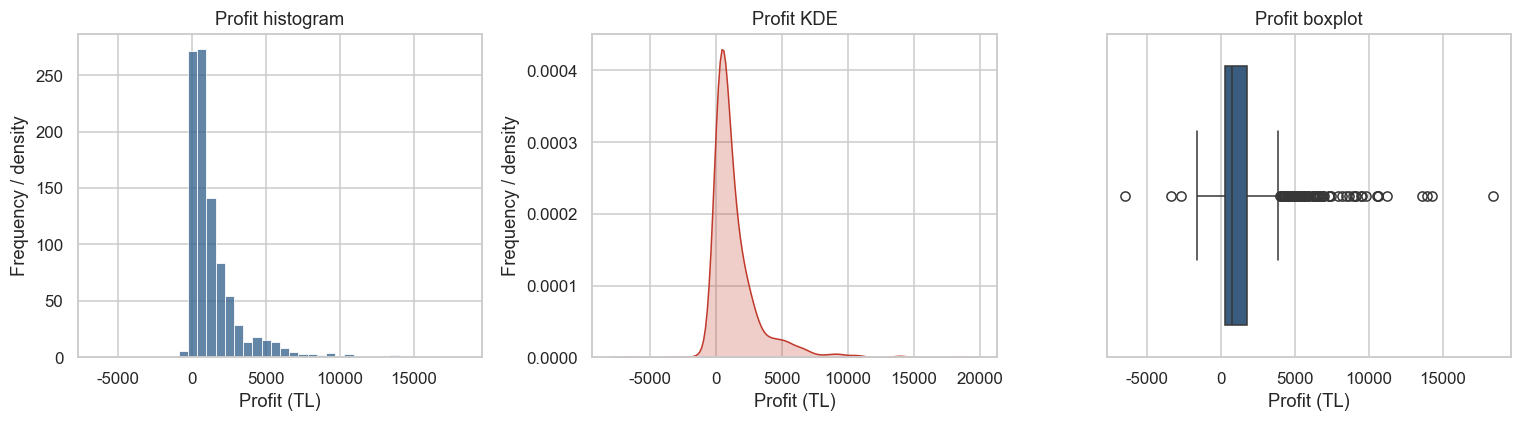

**Target distribution.** Mean (1407.5 TL) is well above the median (759.1 TL). Skewness ≈ 3.01 and excess kurtosis ≈ 14.3: a heavy right tail of large profitable orders, plus 21 losses.

**Transformation decision:** no log / Box-Cox (negatives). Yeo-Johnson was considered and **not applied**. Tree models split on raw TL values; the business metric is profit in TL, not a transformed scale. Transforming `Profit` would force inverse-transform of every metric and would shrink the large orders that matter commercially. Outliers are treated as real orders, not noise.

In [11]:
y = df[TARGET]
target_stats = pd.Series(
    {
        "dtype": str(y.dtype),
        "n": int(y.shape[0]),
        "n_unique": int(y.nunique()),
        "mean": float(y.mean()),
        "median": float(y.median()),
        "std": float(y.std()),
        "min": float(y.min()),
        "max": float(y.max()),
        "skewness": float(y.skew()),
        "kurtosis": float(y.kurtosis()),
        "n_negative": int((y < 0).sum()),
        "n_zero": int((y == 0).sum()),
        "p01": float(y.quantile(0.01)),
        "p99": float(y.quantile(0.99)),
    },
    name="Profit",
)
display(target_stats.to_frame())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(y, bins=40, kde=False, color=PRIMARY, ax=axes[0])
sns.kdeplot(y, color=ACCENT, fill=True, ax=axes[1])
sns.boxplot(x=y, color=PRIMARY, ax=axes[2])
axes[0].set_title("Profit histogram")
axes[1].set_title("Profit KDE")
axes[2].set_title("Profit boxplot")
for ax in axes[:2]:
    ax.set_xlabel("Profit (TL)")
    ax.set_ylabel("Frequency / density")
axes[2].set_xlabel("Profit (TL)")
plt.tight_layout()
plt.show()

annotate(
    f"""**Target distribution.** Mean ({y.mean():.1f} TL) is well above the median ({y.median():.1f} TL). Skewness ≈ {y.skew():.2f} and excess kurtosis ≈ {y.kurtosis():.1f}: a heavy right tail of large profitable orders, plus {(y < 0).sum()} losses.

**Transformation decision:** no log / Box-Cox (negatives). Yeo-Johnson was considered and **not applied**. Tree models split on raw TL values; the business metric is profit in TL, not a transformed scale. Transforming `Profit` would force inverse-transform of every metric and would shrink the large orders that matter commercially. Outliers are treated as real orders, not noise."""
)

# 8. Exploratory Data Analysis

EDA is split into univariate, bivariate (feature → `Profit`) and multivariate (collinearity / redundancy). Findings here drive leakage removals and feature engineering; they are not decorative.

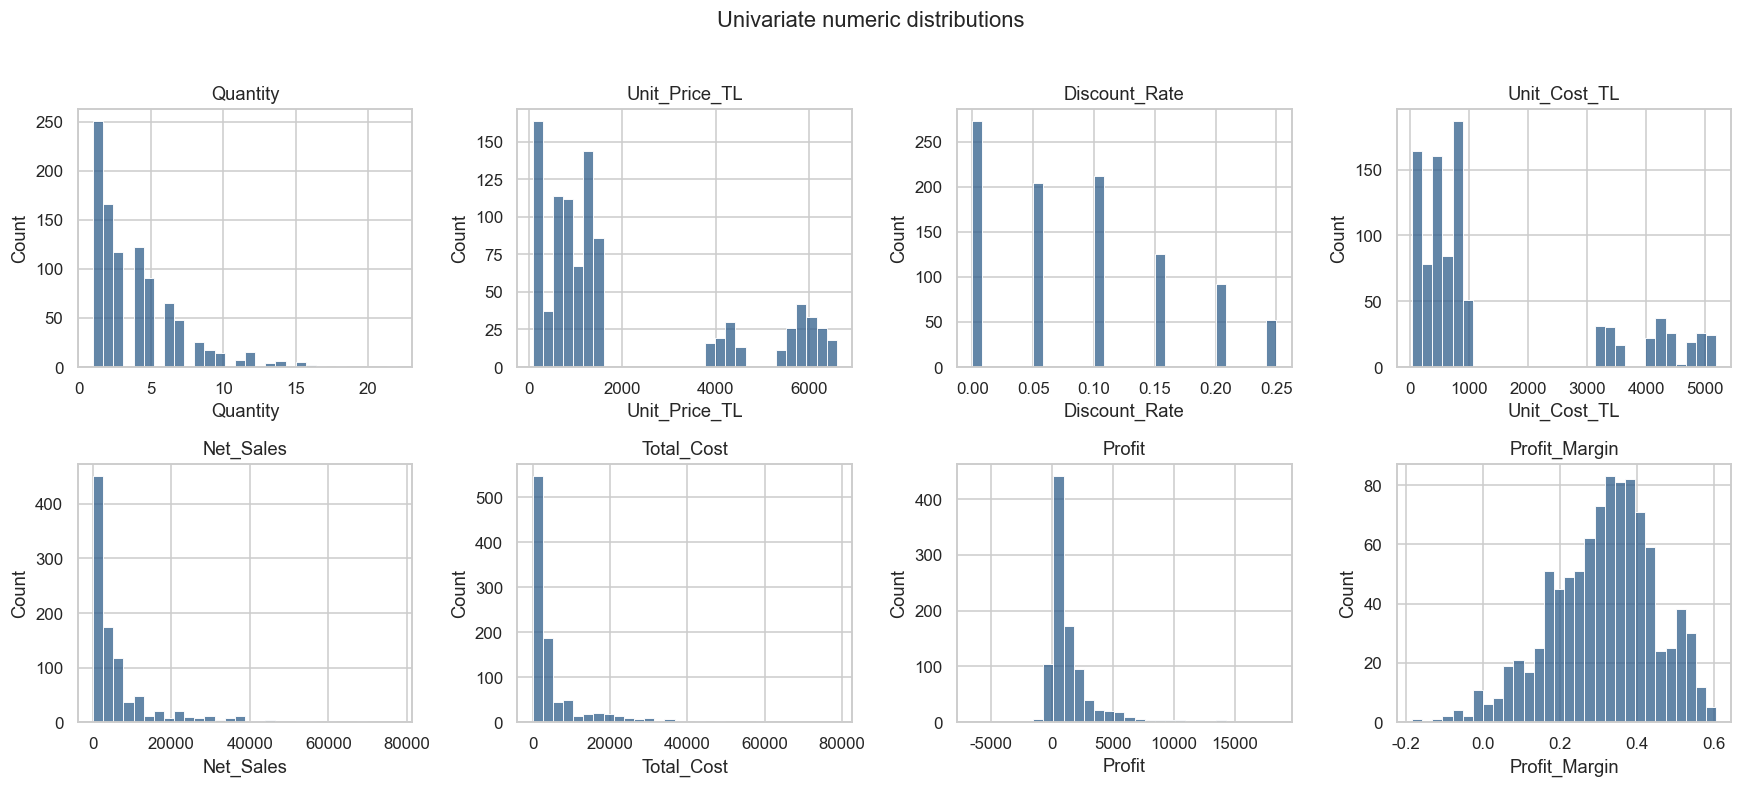

`Quantity` and `Profit`/`Net_Sales`/`Total_Cost` are right-skewed. `Discount_Rate` is discrete. `Unit_Price_TL` and `Unit_Cost_TL` share the same shape — they are economically coupled. `Profit_Margin` is the only roughly symmetric numeric field.

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != "Date"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=30, color=PRIMARY, ax=ax)
    ax.set_title(col)
plt.suptitle("Univariate numeric distributions", y=1.02)
plt.tight_layout()
plt.show()
annotate("`Quantity` and `Profit`/`Net_Sales`/`Total_Cost` are right-skewed. `Discount_Rate` is discrete. `Unit_Price_TL` and `Unit_Cost_TL` share the same shape — they are economically coupled. `Profit_Margin` is the only roughly symmetric numeric field.")

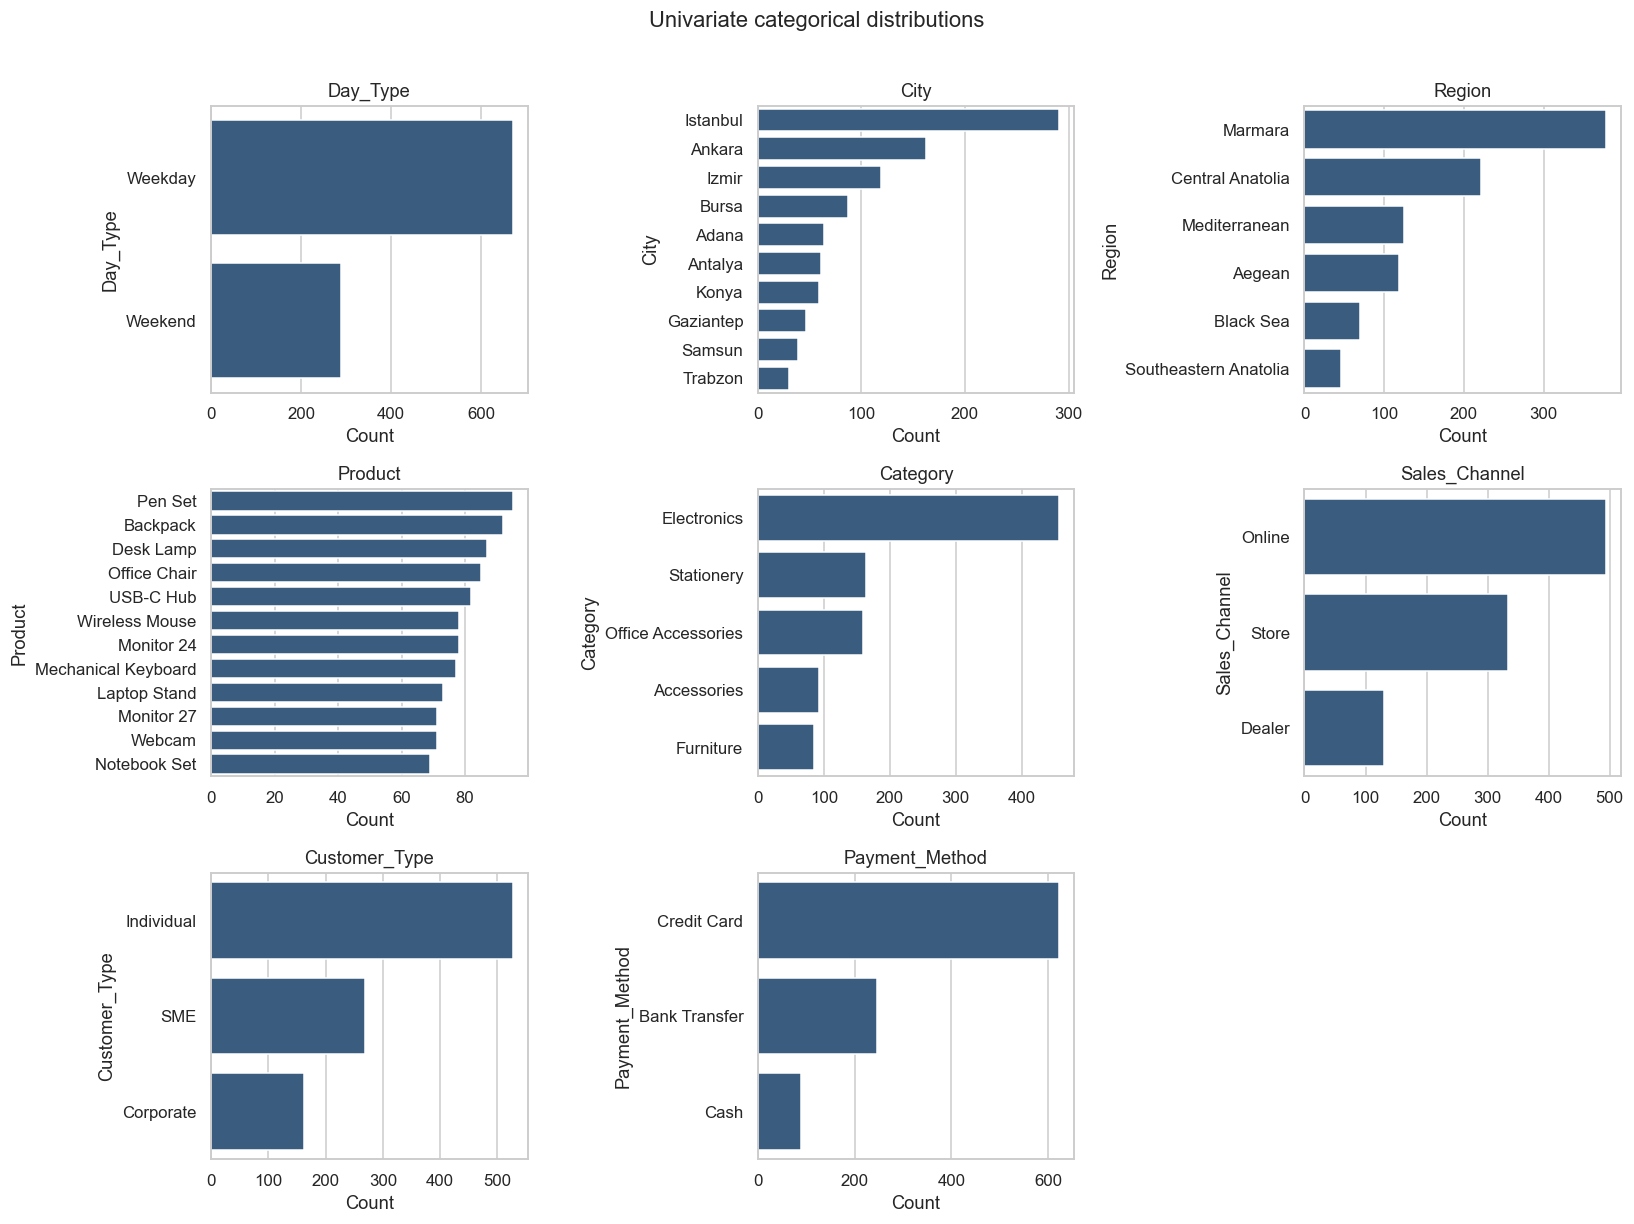

Volume is concentrated in Istanbul, Marmara, Electronics, Online and Individual / Credit Card. Class imbalance is in the **features**, not the target (regression). Rare cities (Trabzon, Samsun) will have higher variance in grouped statistics — another reason not to target-encode without CV.

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
cat_plot_cols = ["Day_Type", "City", "Region", "Product", "Category", "Sales_Channel", "Customer_Type", "Payment_Method"]
for ax, col in zip(axes.ravel(), cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, color=PRIMARY, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Count")
axes.ravel()[-1].axis("off")
plt.suptitle("Univariate categorical distributions", y=1.01)
plt.tight_layout()
plt.show()
annotate("Volume is concentrated in Istanbul, Marmara, Electronics, Online and Individual / Credit Card. Class imbalance is in the **features**, not the target (regression). Rare cities (Trabzon, Samsun) will have higher variance in grouped statistics — another reason not to target-encode without CV.")

Pearson correlation with Profit


,pearson
Profit,1.000000
Net_Sales,0.747754
Total_Cost,0.642984
Unit_Price_TL,0.482327
Quantity,0.459534
Unit_Cost_TL,0.450211
Discount_Rate,-0.281962
Profit_Margin,-0.156903


Spearman correlation with Profit


,spearman
Profit,1.000000
Net_Sales,0.833423
Total_Cost,0.792867
Quantity,0.589065
Unit_Price_TL,0.588477
Unit_Cost_TL,0.561296
Discount_Rate,-0.322819
Profit_Margin,-0.278135


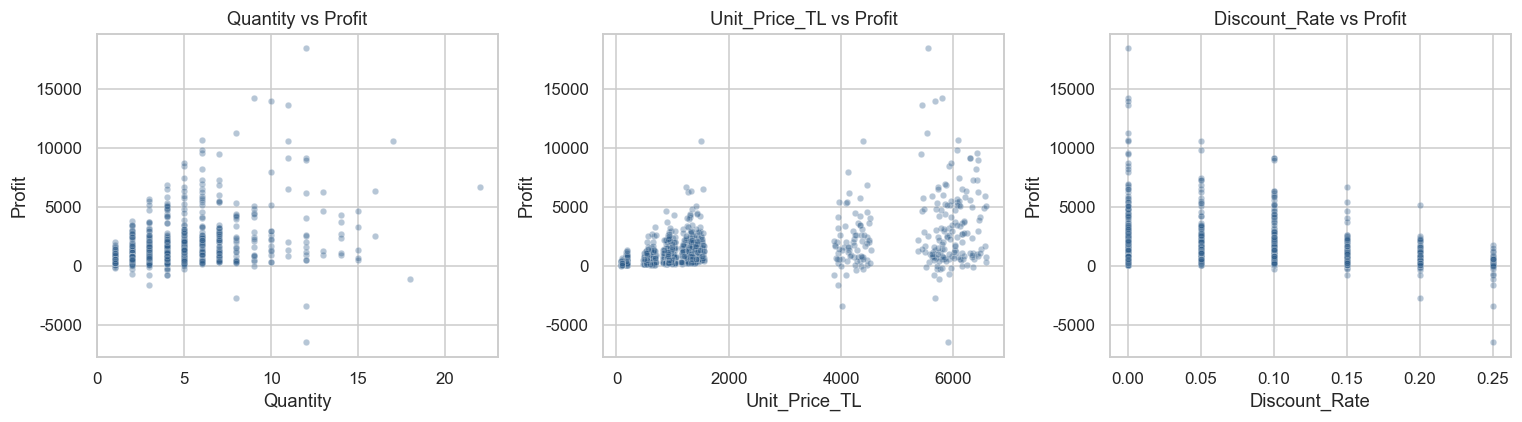

Quantity and unit price have a clear positive association with profit; discount is negative. The fan shape (variance growing with x) is typical of multiplicative pricing and supports MAE/RMSE over R²-only reporting. Spearman vs Pearson differences are modest; the relationships are mostly monotone.

In [14]:
print("Pearson correlation with Profit")
display(df[num_cols].corr(method="pearson")[TARGET].sort_values(key=np.abs, ascending=False).to_frame("pearson"))
print("Spearman correlation with Profit")
display(df[num_cols].corr(method="spearman")[TARGET].sort_values(key=np.abs, ascending=False).to_frame("spearman"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Quantity", "Unit_Price_TL", "Discount_Rate"]):
    sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.35, s=18, color=PRIMARY, ax=ax)
    ax.set_title(f"{col} vs Profit")
plt.tight_layout()
plt.show()
annotate("Quantity and unit price have a clear positive association with profit; discount is negative. The fan shape (variance growing with x) is typical of multiplicative pricing and supports MAE/RMSE over R²-only reporting. Spearman vs Pearson differences are modest; the relationships are mostly monotone.")

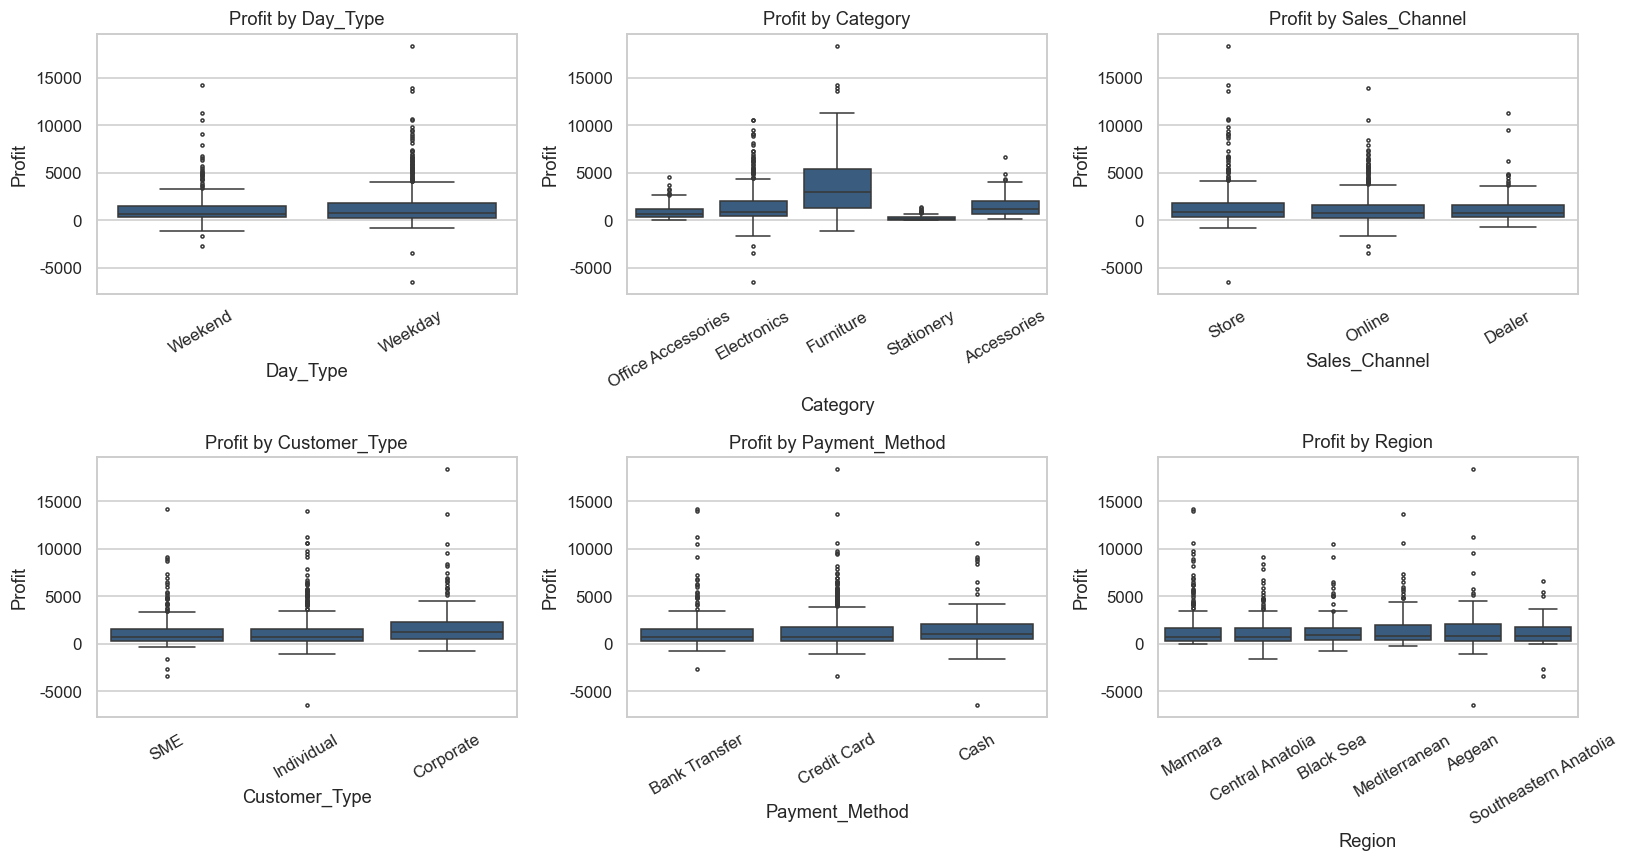

Category and region shift the profit level (Electronics / larger cities have longer upper whiskers). Channel and payment differences are smaller. Weekend vs weekday (`Day_Type`) is not a strong location shift — calendar features may be weak predictors relative to product and quantity.

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["Day_Type", "Category", "Sales_Channel", "Customer_Type", "Payment_Method", "Region"]):
    sns.boxplot(data=df, x=col, y=TARGET, color=PRIMARY, ax=ax, fliersize=2)
    ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"Profit by {col}")
plt.tight_layout()
plt.show()
annotate("Category and region shift the profit level (Electronics / larger cities have longer upper whiskers). Channel and payment differences are smaller. Weekend vs weekday (`Day_Type`) is not a strong location shift — calendar features may be weak predictors relative to product and quantity.")

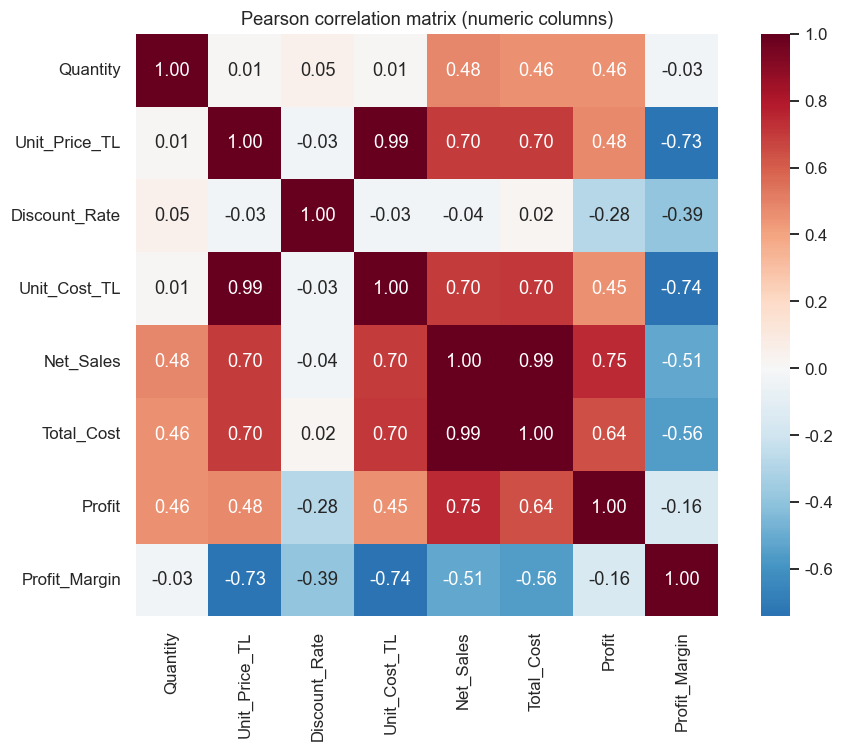

**Multivariate reading**
- `Net_Sales` and `Total_Cost` correlate at ~0.99 — redundant accounting totals.
- `Unit_Price_TL` and `Unit_Cost_TL` also move together (cost is a fraction of price).
- `Profit` correlates 0.75 with `Net_Sales` because profit is a slice of revenue.
- `Profit_Margin` is only weakly related to `Profit` (large orders can have average margins). Margin and profit are different questions.
- Suspicious / leakage-like: any feature that is a **deterministic rearrangement** of the target (`Net_Sales`, `Total_Cost`, `Profit_Margin`, and the cost identity). These are not 'strong predictors' in a useful sense; they are the label in disguise.

In [16]:
corr = df[num_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Pearson correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()
annotate(
    """**Multivariate reading**
- `Net_Sales` and `Total_Cost` correlate at ~0.99 — redundant accounting totals.
- `Unit_Price_TL` and `Unit_Cost_TL` also move together (cost is a fraction of price).
- `Profit` correlates 0.75 with `Net_Sales` because profit is a slice of revenue.
- `Profit_Margin` is only weakly related to `Profit` (large orders can have average margins). Margin and profit are different questions.
- Suspicious / leakage-like: any feature that is a **deterministic rearrangement** of the target (`Net_Sales`, `Total_Cost`, `Profit_Margin`, and the cost identity). These are not 'strong predictors' in a useful sense; they are the label in disguise."""
)

# 9. Feature Analysis

Each column is classified by type and by **whether a production model would know it at prediction time**.

In [17]:
feature_catalog = pd.DataFrame(
    [
        ("Order_ID", "identifier", "drop", "Unique key; no generalisation."),
        ("Date", "datetime", "engineer then drop", "Raw timestamp is not a tree split-friendly feature; extract calendar parts."),
        ("Day_Type", "categorical binary", "drop after FE", "Redundant with `is_weekend` extracted from Date."),
        ("City", "nominal", "keep", "Location demand / mix. One-hot (10 levels)."),
        ("Region", "nominal", "drop", "Deterministic function of City (1:1 mapping)."),
        ("Product", "nominal", "keep", "Product identity. One-hot (12 levels)."),
        ("Category", "nominal", "drop", "Deterministic function of Product."),
        ("Sales_Channel", "nominal", "keep", "Online / store / dealer mix."),
        ("Customer_Type", "nominal", "keep", "Individual / SME / Corporate."),
        ("Payment_Method", "nominal", "keep", "Payment mix; possible proxy for customer segment."),
        ("Quantity", "numeric int", "keep", "Known at order time."),
        ("Unit_Price_TL", "numeric", "keep", "List unit price at order time."),
        ("Discount_Rate", "numeric discrete", "keep", "Commercial term, known at order time. Kept numeric, not one-hot, because order is meaningful."),
        ("Unit_Cost_TL", "numeric", "drop", "Together with qty/price/discount, Profit is an identity. Also internal cost, not a commercial quote field."),
        ("Net_Sales", "derived", "drop", "Target leakage: Profit = Net_Sales - Total_Cost."),
        ("Total_Cost", "derived", "drop", "Target leakage: the other term of the identity."),
        ("Profit_Margin", "derived", "drop", "Profit / Net_Sales — derived from the target."),
        ("Profit", "target", "target", "Order profit in TL."),
    ],
    columns=["feature", "type", "decision", "why"],
)
display(feature_catalog)

print("City -> Region unique mappings:", int(df.groupby("City")["Region"].nunique().max()))
print("Product -> Category unique mappings:", int(df.groupby("Product")["Category"].nunique().max()))
annotate("No text blob columns, no boolean columns other than what we will create (`is_weekend`, month-start/end). No ordinal categoricals with a business rank except `Discount_Rate`, which is already numeric. High-cardinality categoricals are absent — frequency / target encoding is unnecessary.")

,feature,type,decision,why
0,Order_ID,identifier,drop,Unique key; no generalisation.
1,Date,datetime,engineer then drop,Raw timestamp is not a tree split-friendly fea...
2,Day_Type,categorical binary,drop after FE,Redundant with `is_weekend` extracted from Date.
3,City,nominal,keep,Location demand / mix. One-hot (10 levels).
4,Region,nominal,drop,Deterministic function of City (1:1 mapping).
5,Product,nominal,keep,Product identity. One-hot (12 levels).
6,Category,nominal,drop,Deterministic function of Product.
7,Sales_Channel,nominal,keep,Online / store / dealer mix.
8,Customer_Type,nominal,keep,Individual / SME / Corporate.
9,Payment_Method,nominal,keep,Payment mix; possible proxy for customer segment.


City -> Region unique mappings: 1
Product -> Category unique mappings: 1


No text blob columns, no boolean columns other than what we will create (`is_weekend`, month-start/end). No ordinal categoricals with a business rank except `Discount_Rate`, which is already numeric. High-cardinality categoricals are absent — frequency / target encoding is unnecessary.

# 10. Data Leakage Analysis

This is the most important modelling decision in the project.

## 10.1 Accounting identity (target leakage)

\[
Profit = Quantity \times \big(Unit\_Price\_TL \times (1 - Discount\_Rate) - Unit\_Cost\_TL\big)
\]

and equivalently `Profit = Net_Sales - Total_Cost`, `Profit_Margin ≈ Profit / Net_Sales`.

In [18]:
identity = df["Quantity"] * (
    df["Unit_Price_TL"] * (1.0 - df["Discount_Rate"]) - df["Unit_Cost_TL"]
)
oracle_err = (df[TARGET] - identity).abs()
print("Identity vs Profit — max abs error:", float(oracle_err.max()))
print("Identity vs Profit — MAE:", float(oracle_err.mean()))
print("Net_Sales identity max abs error:", float((df["Net_Sales"] - df["Quantity"] * df["Unit_Price_TL"] * (1 - df["Discount_Rate"])).abs().max()))
print("Total_Cost identity max abs error:", float((df["Total_Cost"] - df["Quantity"] * df["Unit_Cost_TL"]).abs().max()))

oracle_metrics = regression_metrics(df[TARGET], identity)
RESULTS["oracle_identity"] = oracle_metrics
display(pd.Series(oracle_metrics, name="accounting_identity").to_frame())
annotate(
    """**Why this is not a model.** R² of this 'predictor' is essentially 1. Residual error is rounding in the Excel file (cents). A learner that receives `Quantity`, `Unit_Price_TL`, `Discount_Rate` and `Unit_Cost_TL` is being asked to rediscover arithmetic.

**Dropped for leakage / identity**
- `Net_Sales`, `Total_Cost`, `Profit_Margin` — post-sale derived fields; would not exist if `Profit` is unknown.
- `Unit_Cost_TL` — the missing term of the identity. Excluding it makes the task: *estimate profit from commercial terms without being given unit cost*.
- `Order_ID` — identifier.

**Kept on purpose:** `Quantity`, `Unit_Price_TL`, `Discount_Rate`. These are quote-time fields. The model must infer the cost structure (mostly product-specific) from `Product` and the commercial terms.

**No target used in preprocessing:** scalers, encoders, mutual information and Optuna fit on train folds only, inside `Pipeline` / `ColumnTransformer`."""
)

Identity vs Profit — max abs error: 0.005000000000563887
Identity vs Profit — MAE: 0.0015944676410900931
Net_Sales identity max abs error: 0.005000000001018634
Total_Cost identity max abs error: 7.275957614183426e-12


,accounting_identity
MAE,0.001594
MSE,0.000005
RMSE,0.002338
R2,1.000000
MedianAE,0.001000
sMAPE,0.000631
MAPE_gt1,0.000631


**Why this is not a model.** R² of this 'predictor' is essentially 1. Residual error is rounding in the Excel file (cents). A learner that receives `Quantity`, `Unit_Price_TL`, `Discount_Rate` and `Unit_Cost_TL` is being asked to rediscover arithmetic.

**Dropped for leakage / identity**
- `Net_Sales`, `Total_Cost`, `Profit_Margin` — post-sale derived fields; would not exist if `Profit` is unknown.
- `Unit_Cost_TL` — the missing term of the identity. Excluding it makes the task: *estimate profit from commercial terms without being given unit cost*.
- `Order_ID` — identifier.

**Kept on purpose:** `Quantity`, `Unit_Price_TL`, `Discount_Rate`. These are quote-time fields. The model must infer the cost structure (mostly product-specific) from `Product` and the commercial terms.

**No target used in preprocessing:** scalers, encoders, mutual information and Optuna fit on train folds only, inside `Pipeline` / `ColumnTransformer`.

# 11. Feature Engineering

All engineered fields are **row-wise**. They do not use another row's target, so they can be computed before the split without leakage. Aggregate encodings (mean profit by city, etc.) are **not** added; those would require a CV-safe encoder.

In [19]:
df_fe = add_rowwise_features(df)

fe_notes = pd.DataFrame(
    [
        ("month / quarter / week_of_year", "Seasonality within the 6-month window (Jan–Jun 2026)."),
        ("day / is_month_start / is_month_end", "Payroll / month-end purchasing cycles."),
        ("day_of_week / is_weekend", "Weekly seasonality; replaces `Day_Type`."),
        ("year", "Will be dropped if constant (single year)."),
        ("net_unit_price", "Price actually charged per unit after discount. Quote-time, not a target derivative."),
        ("list_revenue", "Quantity × list price. Gross commercial size, still without cost."),
        ("discount_value_unit", "Absolute TL discount per unit, complementary to the rate."),
    ],
    columns=["feature", "why"],
)
display(fe_notes)

print("Year unique:", sorted(df_fe["year"].unique().tolist()))
print("Day_Type vs is_weekend cross-tab:")
display(pd.crosstab(df_fe["Day_Type"], df_fe["is_weekend"]))
annotate("`year` is constant (2026) → drop (zero variance). `Day_Type` matches `is_weekend` perfectly → drop `Day_Type` as duplicate. Calendar features are weak a priori (only six months, one year) but cheap to include; feature importance will tell us if they survive.")

,feature,why
0,month / quarter / week_of_year,Seasonality within the 6-month window (Jan–Jun...
1,day / is_month_start / is_month_end,Payroll / month-end purchasing cycles.
2,day_of_week / is_weekend,Weekly seasonality; replaces `Day_Type`.
3,year,Will be dropped if constant (single year).
4,net_unit_price,Price actually charged per unit after discount...
5,list_revenue,"Quantity × list price. Gross commercial size, ..."
6,discount_value_unit,"Absolute TL discount per unit, complementary t..."


Year unique: [2026]
Day_Type vs is_weekend cross-tab:


is_weekend,0,1
Day_Type,,
Weekday,670,0
Weekend,0,288


`year` is constant (2026) → drop (zero variance). `Day_Type` matches `is_weekend` perfectly → drop `Day_Type` as duplicate. Calendar features are weak a priori (only six months, one year) but cheap to include; feature importance will tell us if they survive.

# 12. Encoding & Preprocessing

- **Nominal categoricals** (`City`, `Product`, `Sales_Channel`, `Customer_Type`, `Payment_Method`): `OneHotEncoder(handle_unknown='ignore')`. Cardinality is low (3–12), so OHE is the unbiased default. No target encoding (would need out-of-fold machinery and is unnecessary here).
- **Ordinal:** none besides `Discount_Rate`, already numeric.
- **Numeric:** passed through for tree models (no scaling). Trees split on order statistics; z-scoring does not change those splits and would only matter for PCA / linear models.
- **Imputation:** none — zero missing values.
- **PCA pipeline (diagnostic only):** `StandardScaler` + PCA, separate from the tree pipelines.

In [20]:
LEAKAGE_DROP = ["Order_ID", "Net_Sales", "Total_Cost", "Profit_Margin", "Unit_Cost_TL"]
REDUNDANT_DROP = ["Region", "Category", "Day_Type", "Date", "year"]
DROP_COLS = LEAKAGE_DROP + REDUNDANT_DROP

model_df = df_fe.drop(columns=DROP_COLS)
assert TARGET in model_df.columns

X_all = model_df.drop(columns=[TARGET])
y_all = model_df[TARGET]

CAT_FEATURES = ["City", "Product", "Sales_Channel", "Customer_Type", "Payment_Method"]
NUM_FEATURES = [c for c in X_all.columns if c not in CAT_FEATURES]

print("Numeric features:", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)
print("X shape:", X_all.shape)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUM_FEATURES),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CAT_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
tree_preprocessor

Numeric features: ['Quantity', 'Unit_Price_TL', 'Discount_Rate', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'net_unit_price', 'list_revenue', 'discount_value_unit']
Categorical features: ['City', 'Product', 'Sales_Channel', 'Customer_Type', 'Payment_Method']
X shape: (958, 19)


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


# 13. Feature Selection

Selection is **train-only**. We inspect variance and mutual information after the chronological split (next sections use the same masks). Aggressive `SelectKBest` is not forced: `n ≈ 950`, `p ≈ 40` after OHE, so `p << n`. The risk is leakage, not dimensionality.

# 14. PCA Analysis

**Decision (pre-declared, then verified):** PCA will **not** be used in the XGBoost or Extra Trees pipelines.

Why:
- Both models are tree ensembles. They are invariant to monotone rescaling and handle collinearity by ignoring redundant splits.
- After dropping leakage/nested columns, numeric collinearity is mild.
- PCA would destroy feature names and block SHAP / gain importance, which are project requirements.
- PCA is still **computed** below on scaled train numerics as a diagnostic (scree / 95% variance).

# 15. Train / Test Strategy

The table is a **panel of orders over time** (2026-01-01 → 2026-06-30, 179 distinct days), not an i.i.d. cross-section.

Random 80/20 would put June orders in train and January orders in test — that is future information leaking backward.

**Protocol**
1. Sort by `Date`, then `Order_ID`.
2. Hold out the last 20% of distinct dates as the test set.
3. Inside train, `TimeSeriesSplit(n_splits=5)` for CV / Optuna.
4. Test set is touched only for final evaluation, SHAP, permutation importance and error analysis.

In [21]:
order_idx = df_fe.sort_values(["Date", "Order_ID"]).index
X_all = X_all.loc[order_idx]
y_all = y_all.loc[order_idx]
dates_all = pd.to_datetime(df_fe.loc[order_idx, "Date"])

train_mask, test_mask, cutoff = chronological_masks(dates_all, TEST_SIZE)
X_train, X_test = X_all.loc[train_mask], X_all.loc[test_mask]
y_train, y_test = y_all.loc[train_mask], y_all.loc[test_mask]
dates_train, dates_test = dates_all.loc[train_mask], dates_all.loc[test_mask]

print(f"Cutoff date (first test date): {cutoff.date()}")
print(f"Train: {X_train.shape[0]} rows | {dates_train.min().date()} -> {dates_train.max().date()}")
print(f"Test : {X_test.shape[0]} rows | {dates_test.min().date()} -> {dates_test.max().date()}")
print(f"Train share: {X_train.shape[0] / len(X_all):.1%}  Test share: {X_test.shape[0] / len(X_all):.1%}")
assert dates_train.max() < dates_test.min()

tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
RESULTS["split"] = {
    "cutoff": str(cutoff.date()),
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "train_start": str(dates_train.min().date()),
    "train_end": str(dates_train.max().date()),
    "test_start": str(dates_test.min().date()),
    "test_end": str(dates_test.max().date()),
}

Cutoff date (first test date): 2026-05-26
Train: 743 rows | 2026-01-01 -> 2026-05-25
Test : 215 rows | 2026-05-26 -> 2026-06-30
Train share: 77.6%  Test share: 22.4%


,train_variance
Discount_Rate,0.005428
is_month_end,0.021099
City_Trabzon,0.027502
is_month_start,0.030038
City_Samsun,0.044948
City_Gaziantep,0.051006
City_Antalya,0.058156
City_Konya,0.058156
City_Adana,0.062851
Product_Laptop Stand,0.064015


Near-zero variance columns (< 1e-8): 0


,mutual_info
list_revenue,1.209990
net_unit_price,0.673099
Unit_Price_TL,0.429812
Quantity,0.262571
discount_value_unit,0.216741
Product_Pen Set,0.149056
Discount_Rate,0.086320
Product_Notebook Set,0.068866
Product_Office Chair,0.056857
Product_Monitor 27,0.049700


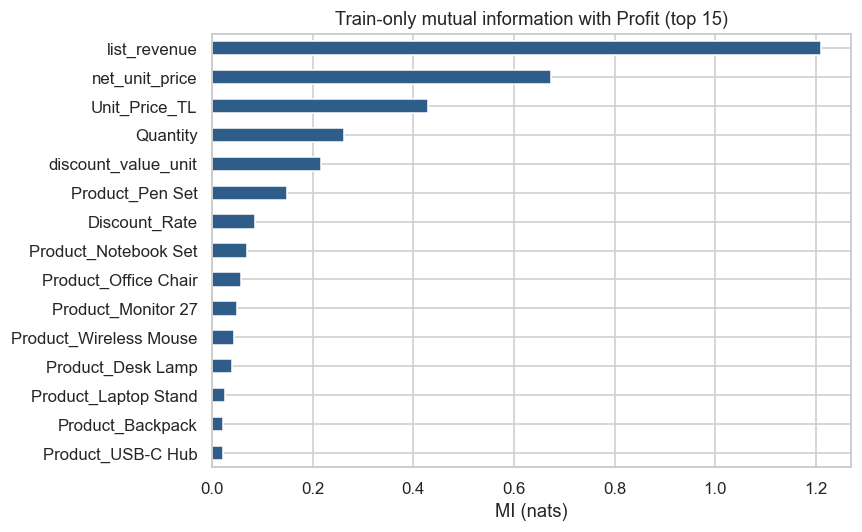

MI ranks commercial size (`list_revenue`, `Quantity`, prices) and some products above calendar flags. No encoded column is constant. **No extra features are dropped** beyond the leakage/redundant set: MI is used as diagnosis, not as a hard filter that could discard weak but stable effects.

In [22]:
# Train-only mutual information and variance (after OHE fit on train)
pre_fs = tree_preprocessor.fit(X_train)
X_train_enc = pd.DataFrame(
    pre_fs.transform(X_train),
    columns=pre_fs.get_feature_names_out(),
    index=X_train.index,
)
variances = X_train_enc.var(axis=0).sort_values()
display(variances.head(10).to_frame("train_variance"))
print("Near-zero variance columns (< 1e-8):", int((variances < 1e-8).sum()))

mi = mutual_info_regression(X_train_enc, y_train, random_state=RANDOM_STATE)
mi_df = pd.Series(mi, index=X_train_enc.columns, name="mutual_info").sort_values(ascending=False)
display(mi_df.head(15).to_frame())

fig, ax = plt.subplots(figsize=(8, 5))
mi_df.head(15).iloc[::-1].plot(kind="barh", color=PRIMARY, ax=ax)
ax.set_title("Train-only mutual information with Profit (top 15)")
ax.set_xlabel("MI (nats)")
plt.tight_layout()
plt.show()
annotate("MI ranks commercial size (`list_revenue`, `Quantity`, prices) and some products above calendar flags. No encoded column is constant. **No extra features are dropped** beyond the leakage/redundant set: MI is used as diagnosis, not as a hard filter that could discard weak but stable effects.")

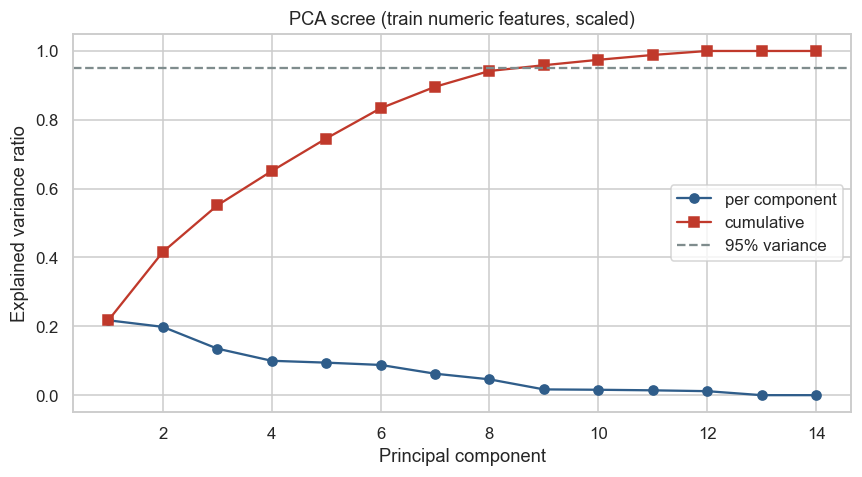

Components needed for 95% variance: 9 / 14


PCA would compress the numeric block to 9 components for 95% variance. That is a mild reduction and is **not worth losing interpretability** for tree models. PCA is not applied to XGBoost or Extra Trees.

In [23]:
# PCA diagnostic on TRAIN numeric features only
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[NUM_FEATURES])
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_num_scaled)
cum = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.searchsorted(cum, 0.95) + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(cum) + 1), pca.explained_variance_ratio_, marker="o", color=PRIMARY, label="per component")
ax.plot(np.arange(1, len(cum) + 1), cum, marker="s", color=ACCENT, label="cumulative")
ax.axhline(0.95, color=MUTED, ls="--", label="95% variance")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree (train numeric features, scaled)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Components needed for 95% variance: {n95} / {len(NUM_FEATURES)}")
RESULTS["pca_n95"] = n95
annotate(f"PCA would compress the numeric block to {n95} components for 95% variance. That is a mild reduction and is **not worth losing interpretability** for tree models. PCA is not applied to XGBoost or Extra Trees.")

# 16. Baseline Model

Two baselines:
1. **Global mean** of train `Profit` — the no-skill regressor.
2. **Product-mean** (train mean `Profit` per `Product`, fallback to global mean) — a strong business heuristic.

ML models must beat both on the **test dates**, not only on train.

In [24]:
baseline_mean = np.full(len(y_test), float(y_train.mean()))
baseline_median = np.full(len(y_test), float(y_train.median()))
product_means = y_train.groupby(X_train["Product"]).mean()
baseline_product = X_test["Product"].map(product_means).fillna(y_train.mean()).to_numpy()

RESULTS["baseline_mean"] = regression_metrics(y_test, baseline_mean)
RESULTS["baseline_median"] = regression_metrics(y_test, baseline_median)
RESULTS["baseline_product"] = regression_metrics(y_test, baseline_product)
display(metrics_frame({k: RESULTS[k] for k in ["baseline_mean", "baseline_median", "baseline_product"]}))
annotate("The product-mean baseline captures assortment mix. Any claimed ML lift will be measured against this, not only against the global mean.")

,MAE,MSE,RMSE,R2,MedianAE,sMAPE,MAPE_gt1
baseline_mean,1281.7059,3.377430e+06,1837.7786,-0.0044,1016.5834,92.5292,462.7526
baseline_median,1124.8418,3.667810e+06,1915.1528,-0.0908,550.7100,86.8908,239.5482
baseline_product,1026.1241,2.626781e+06,1620.7348,0.2188,587.4110,74.1463,447.5082


The product-mean baseline captures assortment mix. Any claimed ML lift will be measured against this, not only against the global mean.

# 17. XGBoost Model

XGBoost is the required primary learner: it handles mixed tabular features, nonlinear interactions (quantity × product, discount × price) and the skewed target without a Gaussian assumption.

Default model first (sanity check), then Optuna tuning with `TimeSeriesSplit`.

In [25]:
def make_xgb(params: dict | None = None) -> Pipeline:
    cfg = {
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "tree_method": "hist",
        "verbosity": 0,
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.08,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 2,
        "reg_lambda": 1.0,
    }
    if params:
        cfg.update(params)
    return Pipeline(
        [
            ("pre", tree_preprocessor),
            ("model", XGBRegressor(**cfg)),
        ]
    )


def cv_mae(estimator, X, y, cv) -> np.ndarray:
    scores = []
    for tr, va in cv.split(X):
        est = estimator
        # clone via new pipeline: caller passes a factory-built pipeline each time
        est.fit(X.iloc[tr], y.iloc[tr])
        pred = est.predict(X.iloc[va])
        scores.append(mean_absolute_error(y.iloc[va], pred))
    return np.asarray(scores, dtype=float)


xgb_default = make_xgb()
xgb_default_cv = cv_mae(xgb_default, X_train, y_train, tscv)
print("XGBoost default TimeSeriesSplit MAE:", np.round(xgb_default_cv, 2), "mean=", round(xgb_default_cv.mean(), 2))
xgb_default.fit(X_train, y_train)
RESULTS["xgb_default_cv_mae"] = float(xgb_default_cv.mean())
RESULTS["xgb_default_train"] = regression_metrics(y_train, xgb_default.predict(X_train))
RESULTS["xgb_default_test"] = regression_metrics(y_test, xgb_default.predict(X_test))
display(metrics_frame({"train": RESULTS["xgb_default_train"], "test": RESULTS["xgb_default_test"]}))
annotate("Default XGBoost is a reference point. A large train/test gap here would already flag overfitting before tuning (tuning can make that worse if unconstrained).")

XGBoost default TimeSeriesSplit MAE: [478.61 318.24 250.05 264.96 238.67] mean= 310.11


,MAE,MSE,RMSE,R2,MedianAE,sMAPE,MAPE_gt1
train,39.9817,3264.8703,57.1390,0.9992,27.6520,7.4611,7.3535
test,290.3575,692800.2220,832.3462,0.7940,81.0716,25.4042,83.0137


Default XGBoost is a reference point. A large train/test gap here would already flag overfitting before tuning (tuning can make that worse if unconstrained).

# 18. Second Model Selection

## Why Extra Trees as the second model?

Candidates considered: Random Forest, Extra Trees, HistGradientBoosting, LightGBM, CatBoost.

| Candidate | Verdict |
|-----------|---------|
| CatBoost | Strong with categoricals, but cardinality here is only 3–12. OHE is sufficient; extra dependency is not justified. |
| LightGBM | Very similar inductive bias to XGBoost (boosted trees). A weak contrast. |
| HistGradientBoosting | Same family as LightGBM/XGBoost. |
| Random Forest | Valid bagging contrast, slightly more correlated trees than Extra Trees. |
| **Extra Trees** | **Selected.** |

**Technical reasons**
1. **Different paradigm:** bagging with random split thresholds vs gradient boosting. If Extra Trees ≈ XGBoost, the signal is in the features; if XGBoost wins clearly, residual boosting is doing real work.
2. **Outlier robustness:** extra randomization regularizes against the heavy-tailed `Profit` distribution.
3. **No scaling required** — same preprocessor as XGBoost, fair comparison.
4. **Native feature importances** for a head-to-head with XGBoost gain/weight.
5. **Zero extra runtime dependency** beyond scikit-learn.

The comparison is therefore **boosting vs extremely randomized bagging** on the same leakage-safe feature pipeline.

# 19. Second Model Training

In [26]:
def make_et(params: dict | None = None) -> Pipeline:
    cfg = {
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "n_estimators": 400,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
    }
    if params:
        cfg.update(params)
    return Pipeline(
        [
            ("pre", tree_preprocessor),
            ("model", ExtraTreesRegressor(**cfg)),
        ]
    )


et_default = make_et()
et_default_cv = cv_mae(et_default, X_train, y_train, tscv)
print("Extra Trees default TimeSeriesSplit MAE:", np.round(et_default_cv, 2), "mean=", round(et_default_cv.mean(), 2))
et_default.fit(X_train, y_train)
RESULTS["et_default_cv_mae"] = float(et_default_cv.mean())
RESULTS["et_default_train"] = regression_metrics(y_train, et_default.predict(X_train))
RESULTS["et_default_test"] = regression_metrics(y_test, et_default.predict(X_test))
display(metrics_frame({"train": RESULTS["et_default_train"], "test": RESULTS["et_default_test"]}))

Extra Trees default TimeSeriesSplit MAE: [909.38 561.38 651.85 590.52 486.3 ] mean= 639.89


,MAE,MSE,RMSE,R2,MedianAE,sMAPE,MAPE_gt1
train,261.7509,2.856864e+05,534.4964,0.9291,114.3621,25.7253,42.5958
test,531.6792,1.258552e+06,1121.8520,0.6257,232.8509,43.3541,293.3460


# 20. Hyperparameter Optimization

Optuna TPE, `TPESampler(seed=42)`, 20 trials per model. Objective = mean MAE on `TimeSeriesSplit` **train folds only**. Search spaces are compact (no combinatorial explosion).

Primary optimisation metric: **MAE**. RMSE is monitored on the test set later; it is not the Optuna objective because a few large orders would dominate the search.

In [27]:
def optuna_xgb(n_trials: int = N_TRIALS):
    def objective(trial: optuna.Trial) -> float:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0.0, 2.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        }
        pipe = make_xgb(params)
        return float(cv_mae(pipe, X_train, y_train, tscv).mean())

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name="xgb_kar",
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def optuna_et(n_trials: int = N_TRIALS):
    def objective(trial: optuna.Trial) -> float:
        max_depth = trial.suggest_int("max_depth", 6, 24)
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 600),
            "max_depth": max_depth,
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
        }
        pipe = make_et(params)
        return float(cv_mae(pipe, X_train, y_train, tscv).mean())

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name="et_kar",
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


study_xgb = optuna_xgb()
study_et = optuna_et()
print("XGBoost best CV MAE:", round(study_xgb.best_value, 3))
print("XGBoost best params:", study_xgb.best_params)
print("Extra Trees best CV MAE:", round(study_et.best_value, 3))
print("Extra Trees best params:", study_et.best_params)
RESULTS["xgb_best_params"] = study_xgb.best_params
RESULTS["et_best_params"] = study_et.best_params
RESULTS["xgb_tuned_cv_mae"] = float(study_xgb.best_value)
RESULTS["et_tuned_cv_mae"] = float(study_et.best_value)

XGBoost best CV MAE: 305.408
XGBoost best params: {'n_estimators': 243, 'max_depth': 5, 'learning_rate': 0.05544514534944357, 'subsample': 0.7020471136043668, 'colsample_bytree': 0.991594186044385, 'min_child_weight': 3, 'gamma': 1.736881261874429, 'reg_alpha': 0.726775165034454, 'reg_lambda': 0.5496358312083061}
Extra Trees best CV MAE: 396.741
Extra Trees best params: {'max_depth': 20, 'n_estimators': 476, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5}


# 21. Cross Validation

Tuned pipelines are re-evaluated fold-by-fold so the CV distribution (not only the Optuna scalar) is visible. Fold scores should be stable; a single exploding fold would mean the model depends on a short time window.

,fold,XGBoost_MAE,ExtraTrees_MAE
0,1,494.260,698.707
1,2,317.375,368.479
2,3,237.703,339.766
3,4,263.271,304.640
4,5,214.433,272.112
mean,,305.408,396.741
std,,112.299,172.658


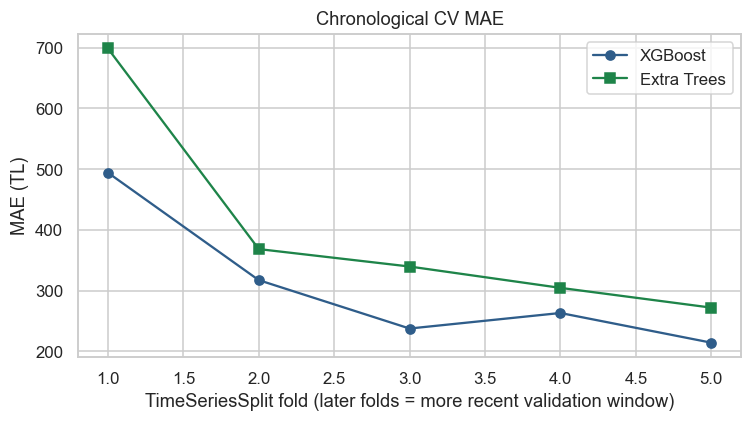

Later folds validate on more recent train-period months. An upward trend would mean concept drift inside H1 2026; a flat band means the relationship is reasonably stable.

In [28]:
xgb_tuned = make_xgb(study_xgb.best_params)
et_tuned = make_et(study_et.best_params)

xgb_cv_scores = cv_mae(xgb_tuned, X_train, y_train, tscv)
et_cv_scores = cv_mae(et_tuned, X_train, y_train, tscv)

cv_table = pd.DataFrame(
    {
        "fold": np.arange(1, CV_FOLDS + 1),
        "XGBoost_MAE": xgb_cv_scores,
        "ExtraTrees_MAE": et_cv_scores,
    }
)
cv_table.loc["mean"] = ["", xgb_cv_scores.mean(), et_cv_scores.mean()]
cv_table.loc["std"] = ["", xgb_cv_scores.std(ddof=1), et_cv_scores.std(ddof=1)]
display(cv_table.round(3))
RESULTS["xgb_cv_folds"] = xgb_cv_scores.tolist()
RESULTS["et_cv_folds"] = et_cv_scores.tolist()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, CV_FOLDS + 1), xgb_cv_scores, marker="o", color=PRIMARY, label="XGBoost")
ax.plot(np.arange(1, CV_FOLDS + 1), et_cv_scores, marker="s", color=SECOND, label="Extra Trees")
ax.set_xlabel("TimeSeriesSplit fold (later folds = more recent validation window)")
ax.set_ylabel("MAE (TL)")
ax.set_title("Chronological CV MAE")
ax.legend()
plt.tight_layout()
plt.show()
annotate("Later folds validate on more recent train-period months. An upward trend would mean concept drift inside H1 2026; a flat band means the relationship is reasonably stable.")

# 22. Model Evaluation

Pipelines are refit on the **full training period**, then scored once on the future test dates. Test predictions are not used to pick hyperparameters.

In [29]:
xgb_final = make_xgb(study_xgb.best_params)
et_final = make_et(study_et.best_params)
xgb_final.fit(X_train, y_train)
et_final.fit(X_train, y_train)

xgb_train_pred = xgb_final.predict(X_train)
xgb_test_pred = xgb_final.predict(X_test)
et_train_pred = et_final.predict(X_train)
et_test_pred = et_final.predict(X_test)

RESULTS["xgb_train"] = regression_metrics(y_train, xgb_train_pred)
RESULTS["xgb_test"] = regression_metrics(y_test, xgb_test_pred)
RESULTS["et_train"] = regression_metrics(y_train, et_train_pred)
RESULTS["et_test"] = regression_metrics(y_test, et_test_pred)

eval_table = metrics_frame(
    {
        "XGBoost train": RESULTS["xgb_train"],
        "XGBoost test": RESULTS["xgb_test"],
        "ExtraTrees train": RESULTS["et_train"],
        "ExtraTrees test": RESULTS["et_test"],
        "Product-mean test": RESULTS["baseline_product"],
        "Mean test": RESULTS["baseline_mean"],
    }
)
display(eval_table)
annotate("Read **test** rows as generalisation. Train metrics are only for the overfitting check. MAPE_gt1 excludes |Profit| ≤ 1 TL and remains a diagnostic, not a selection criterion.")

,MAE,MSE,RMSE,R2,MedianAE,sMAPE,MAPE_gt1
XGBoost train,58.8916,9.487534e+03,97.4040,0.9976,36.8283,9.2140,10.2683
XGBoost test,279.1393,7.590181e+05,871.2164,0.7743,68.8737,22.1682,77.3063
ExtraTrees train,101.3281,7.628962e+04,276.2057,0.9811,24.3486,8.3709,13.5789
ExtraTrees test,322.7799,8.337758e+05,913.1132,0.7520,83.3456,22.5763,197.9950
Product-mean test,1026.1241,2.626781e+06,1620.7348,0.2188,587.4110,74.1463,447.5082
Mean test,1281.7059,3.377430e+06,1837.7786,-0.0044,1016.5834,92.5292,462.7526


Read **test** rows as generalisation. Train metrics are only for the overfitting check. MAPE_gt1 excludes |Profit| ≤ 1 TL and remains a diagnostic, not a selection criterion.

# 23. Model Comparison

In [30]:
comparison = pd.DataFrame(
    {
        "Model": ["Mean baseline", "Product-mean baseline", "XGBoost", "Extra Trees"],
        "CV_MAE": [
            np.nan,
            np.nan,
            RESULTS["xgb_tuned_cv_mae"],
            RESULTS["et_tuned_cv_mae"],
        ],
        "Test_MAE": [
            RESULTS["baseline_mean"]["MAE"],
            RESULTS["baseline_product"]["MAE"],
            RESULTS["xgb_test"]["MAE"],
            RESULTS["et_test"]["MAE"],
        ],
        "Test_RMSE": [
            RESULTS["baseline_mean"]["RMSE"],
            RESULTS["baseline_product"]["RMSE"],
            RESULTS["xgb_test"]["RMSE"],
            RESULTS["et_test"]["RMSE"],
        ],
        "Test_R2": [
            RESULTS["baseline_mean"]["R2"],
            RESULTS["baseline_product"]["R2"],
            RESULTS["xgb_test"]["R2"],
            RESULTS["et_test"]["R2"],
        ],
        "Test_MedianAE": [
            RESULTS["baseline_mean"]["MedianAE"],
            RESULTS["baseline_product"]["MedianAE"],
            RESULTS["xgb_test"]["MedianAE"],
            RESULTS["et_test"]["MedianAE"],
        ],
        "Test_sMAPE": [
            RESULTS["baseline_mean"]["sMAPE"],
            RESULTS["baseline_product"]["sMAPE"],
            RESULTS["xgb_test"]["sMAPE"],
            RESULTS["et_test"]["sMAPE"],
        ],
        "Train_MAE": [
            np.nan,
            np.nan,
            RESULTS["xgb_train"]["MAE"],
            RESULTS["et_train"]["MAE"],
        ],
    }
).round(3)
display(comparison)
RESULTS["comparison"] = comparison

xgb_gap = RESULTS["xgb_train"]["MAE"] / max(RESULTS["xgb_test"]["MAE"], 1e-9)
et_gap = RESULTS["et_train"]["MAE"] / max(RESULTS["et_test"]["MAE"], 1e-9)
annotate(
    f"""**How to read the table (not 'highest R² wins')**
- **Generalisation:** test MAE / RMSE vs product-mean baseline.
- **Stability:** CV MAE vs test MAE. A much worse test score than CV implies temporal drift.
- **Overfitting:** train MAE << test MAE. XGBoost train/test MAE ratio = {xgb_gap:.2f}; Extra Trees = {et_gap:.2f} (1.0 = no gap, <<1 = overfit).
- **Error distribution:** MedianAE vs MAE; if MAE >> MedianAE the mean is pulled by a few large misses.
- **Interpretability / cost:** both are tree ensembles; Extra Trees is usually cheaper to train, XGBoost usually cheaper to predict at the same `n_estimators`."""
)

,Model,CV_MAE,Test_MAE,Test_RMSE,Test_R2,Test_MedianAE,Test_sMAPE,Train_MAE
0,Mean baseline,NaN,1281.706,1837.779,-0.004,1016.583,92.529,NaN
1,Product-mean baseline,NaN,1026.124,1620.735,0.219,587.411,74.146,NaN
2,XGBoost,305.408,279.139,871.216,0.774,68.874,22.168,58.892
3,Extra Trees,396.741,322.780,913.113,0.752,83.346,22.576,101.328


**How to read the table (not 'highest R² wins')**
- **Generalisation:** test MAE / RMSE vs product-mean baseline.
- **Stability:** CV MAE vs test MAE. A much worse test score than CV implies temporal drift.
- **Overfitting:** train MAE << test MAE. XGBoost train/test MAE ratio = 0.21; Extra Trees = 0.31 (1.0 = no gap, <<1 = overfit).
- **Error distribution:** MedianAE vs MAE; if MAE >> MedianAE the mean is pulled by a few large misses.
- **Interpretability / cost:** both are tree ensembles; Extra Trees is usually cheaper to train, XGBoost usually cheaper to predict at the same `n_estimators`.

# 24. Feature Importance

Three views, because they answer different questions:
- **XGBoost gain** — total loss reduction attributed to a feature.
- **XGBoost weight** — how often the feature is used for a split.
- **Permutation importance (test)** — increase in MAE when the feature is shuffled after the model is frozen.

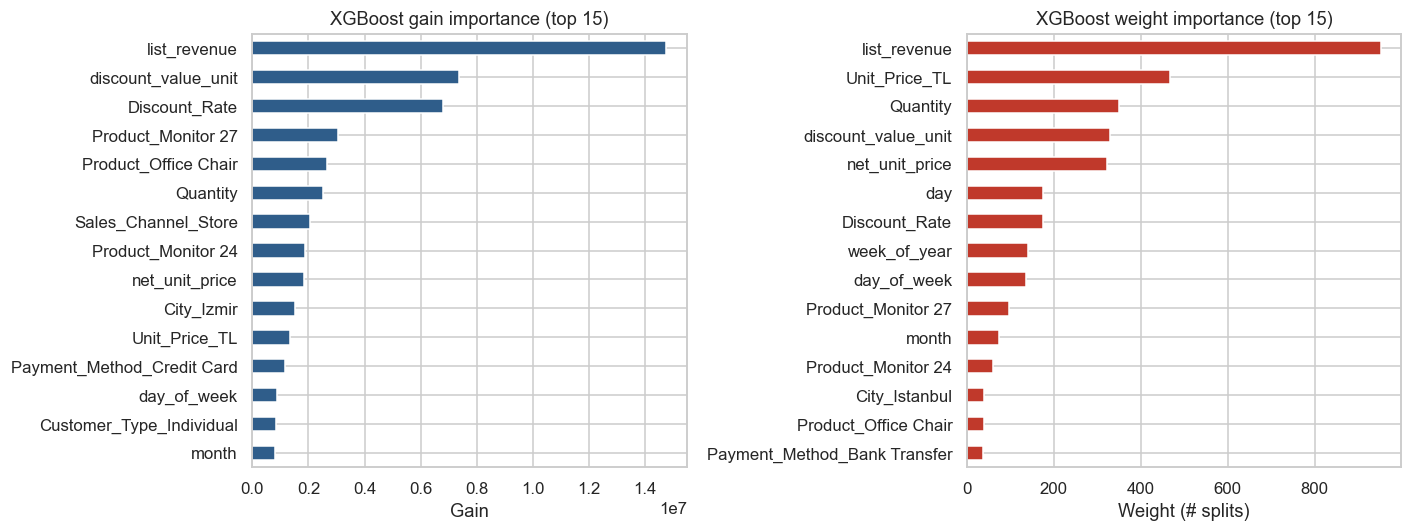

,gain,weight
list_revenue,1.475857e+07,952.0
discount_value_unit,7.363684e+06,330.0
Discount_Rate,6.779898e+06,174.0
Product_Monitor 27,3.051595e+06,97.0
Product_Office Chair,2.655757e+06,40.0
Quantity,2.521276e+06,351.0
Sales_Channel_Store,2.058996e+06,30.0
Product_Monitor 24,1.865606e+06,59.0
net_unit_price,1.849560e+06,322.0
City_Izmir,1.506030e+06,28.0


In [31]:
def encoded_feature_names(pipeline: Pipeline) -> np.ndarray:
    return pipeline.named_steps["pre"].get_feature_names_out()


xgb_model = xgb_final.named_steps["model"]
feat_names = encoded_feature_names(xgb_final)

gain = pd.Series(xgb_model.get_booster().get_score(importance_type="gain"), name="gain")
weight = pd.Series(xgb_model.get_booster().get_score(importance_type="weight"), name="weight")
# booster uses f0, f1, ... mapped to column order
mapper = {f"f{i}": name for i, name in enumerate(feat_names)}
gain.index = [mapper.get(i, i) for i in gain.index]
weight.index = [mapper.get(i, i) for i in weight.index]
imp_xgb = pd.concat([gain, weight], axis=1).fillna(0.0).sort_values("gain", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
imp_xgb["gain"].head(15).iloc[::-1].plot(kind="barh", ax=axes[0], color=PRIMARY)
imp_xgb["weight"].sort_values().tail(15).plot(kind="barh", ax=axes[1], color=ACCENT)
axes[0].set_title("XGBoost gain importance (top 15)")
axes[1].set_title("XGBoost weight importance (top 15)")
axes[0].set_xlabel("Gain")
axes[1].set_xlabel("Weight (# splits)")
plt.tight_layout()
plt.show()
display(imp_xgb.head(15))
RESULTS["xgb_top_gain"] = imp_xgb["gain"].head(10).to_dict()

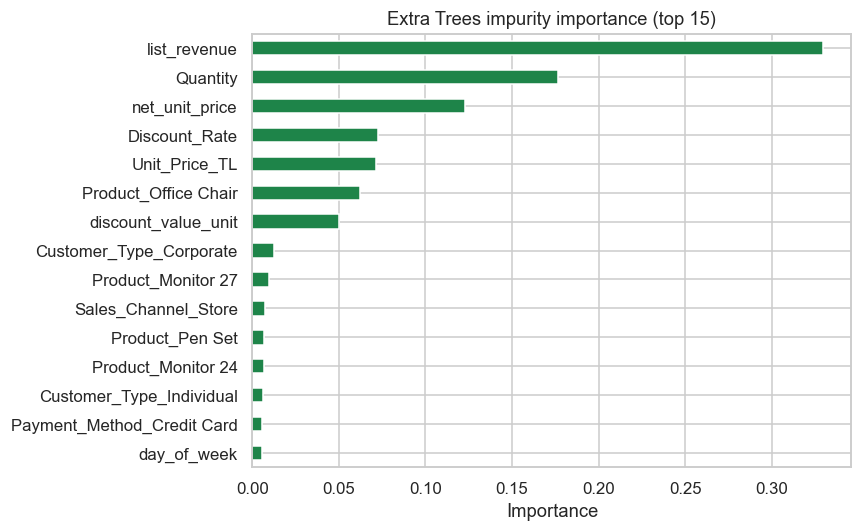

,feature,xgb_perm_MAE,et_perm_MAE
17,list_revenue,1388.136333,7.325432e+02
18,discount_value_unit,368.371047,7.028187e+01
1,Product,121.819367,9.200671e+01
5,Unit_Price_TL,103.593588,1.021859e+02
6,Discount_Rate,103.067267,1.594819e+02
16,net_unit_price,80.528028,2.173538e+02
4,Quantity,65.908350,2.941098e+02
7,Payment_Method,2.981322,-1.519921e+00
10,day_of_week,2.803935,-1.119180e+00
0,City,1.341351,6.424729e+00


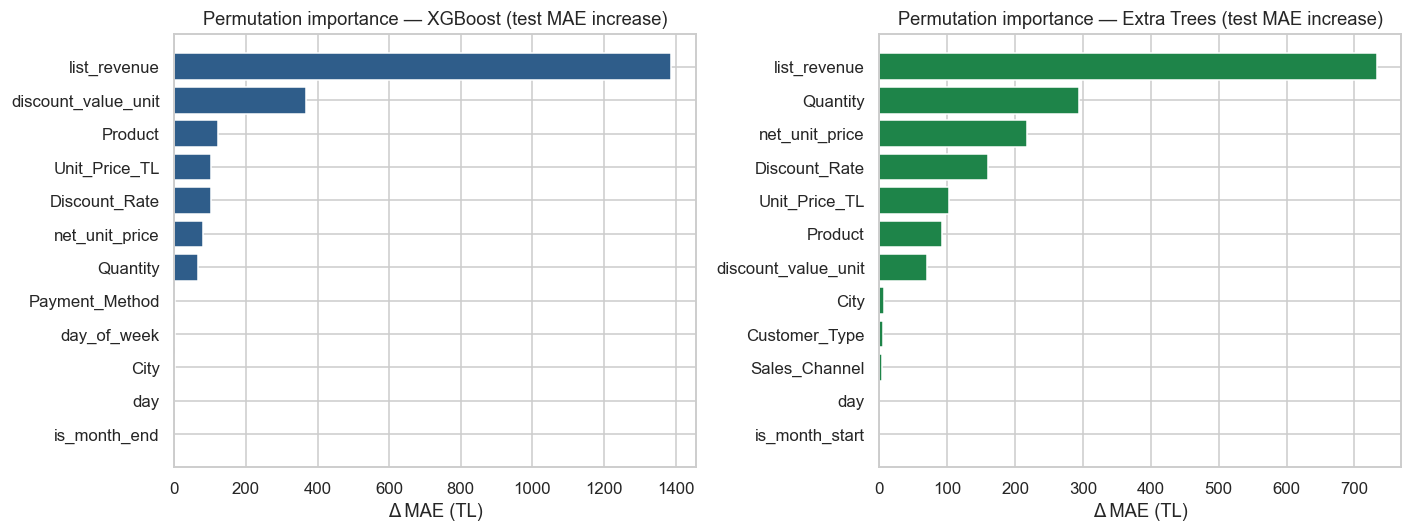

Permutation importance is computed on **raw input columns** (before OHE), so `Product` is one feature, not 12 dummies. That is closer to a business question: 'if we did not know the product, how much would MAE degrade?'

In [32]:
et_imp = pd.Series(
    et_final.named_steps["model"].feature_importances_,
    index=encoded_feature_names(et_final),
    name="et_impurity",
).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
et_imp.head(15).iloc[::-1].plot(kind="barh", color=SECOND, ax=ax)
ax.set_title("Extra Trees impurity importance (top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

perm_xgb = permutation_importance(
    xgb_final,
    X_test,
    y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)
perm_et = permutation_importance(
    et_final,
    X_test,
    y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)
perm_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "xgb_perm_MAE": perm_xgb.importances_mean,
        "et_perm_MAE": perm_et.importances_mean,
    }
).sort_values("xgb_perm_MAE", ascending=False)
display(perm_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tmp = perm_df.head(12)
axes[0].barh(tmp["feature"].iloc[::-1], tmp["xgb_perm_MAE"].iloc[::-1], color=PRIMARY)
axes[1].barh(
    perm_df.sort_values("et_perm_MAE").tail(12)["feature"],
    perm_df.sort_values("et_perm_MAE").tail(12)["et_perm_MAE"],
    color=SECOND,
)
axes[0].set_title("Permutation importance — XGBoost (test MAE increase)")
axes[1].set_title("Permutation importance — Extra Trees (test MAE increase)")
axes[0].set_xlabel("Δ MAE (TL)")
axes[1].set_xlabel("Δ MAE (TL)")
plt.tight_layout()
plt.show()
RESULTS["perm_top"] = perm_df.head(8)["feature"].tolist()
annotate("Permutation importance is computed on **raw input columns** (before OHE), so `Product` is one feature, not 12 dummies. That is closer to a business question: 'if we did not know the product, how much would MAE degrade?'")

# 25. SHAP Explainability

SHAP is run on the final selected model after comparison. Encoded test features keep their names via ColumnTransformer.get_feature_names_out().

Why not shap.TreeExplainer on XGBoost 3.x: shap 0.46 cannot parse XGBoost 3 base_score (stored as a JSON list string). That is a library mismatch, not a modelling issue. XGBoost pred_contribs implements the same TreeSHAP algorithm, so the values are still SHAP contributions. Extra Trees still uses shap.TreeExplainer.

SHAP host model: XGBoost


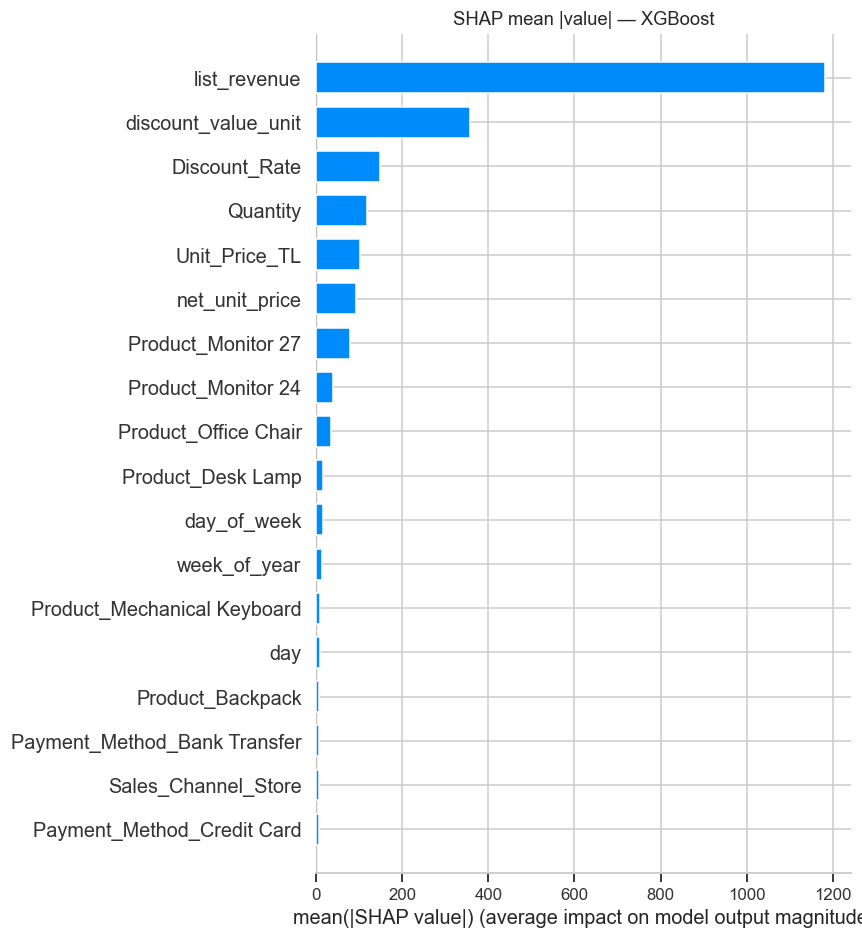

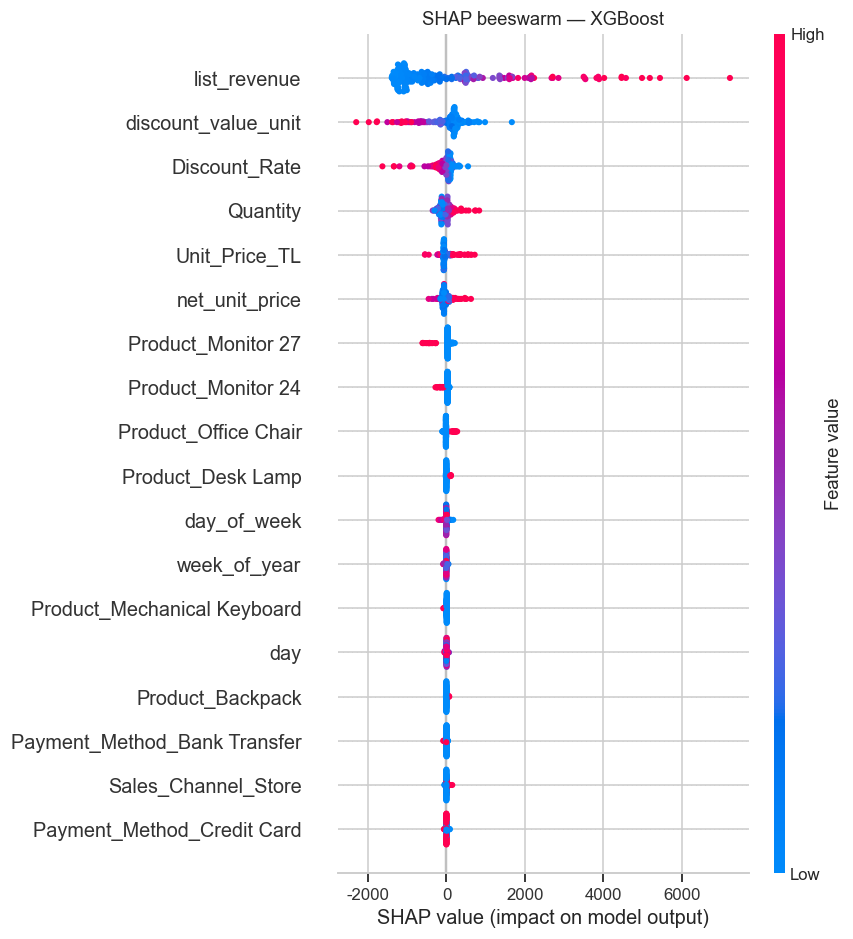

,mean_abs_shap
list_revenue,1182.570679
discount_value_unit,357.132019
Discount_Rate,147.280609
Quantity,118.327972
Unit_Price_TL,102.399231
net_unit_price,91.729660
Product_Monitor 27,79.091621
Product_Monitor 24,39.345318
Product_Office Chair,35.253578
Product_Desk Lamp,16.058136


Beeswarm colour is the feature value. A high `list_revenue` (red) pushing SHAP positive means large list totals increase predicted profit — the economically expected direction, without using cost or `Net_Sales`.

In [33]:
# Decide final model by test MAE (primary), then test RMSE as tie-breaker
xgb_is_better = (
    RESULTS["xgb_test"]["MAE"] < RESULTS["et_test"]["MAE"]
    or (
        np.isclose(RESULTS["xgb_test"]["MAE"], RESULTS["et_test"]["MAE"])
        and RESULTS["xgb_test"]["RMSE"] <= RESULTS["et_test"]["RMSE"]
    )
)
final_name = "XGBoost" if xgb_is_better else "Extra Trees"
final_pipe = xgb_final if xgb_is_better else et_final
final_estimator = final_pipe.named_steps["model"]
print("SHAP host model:", final_name)

X_test_enc = pd.DataFrame(
    final_pipe.named_steps["pre"].transform(X_test),
    columns=final_pipe.named_steps["pre"].get_feature_names_out(),
    index=X_test.index,
)
X_train_enc_final = pd.DataFrame(
    final_pipe.named_steps["pre"].transform(X_train),
    columns=X_test_enc.columns,
    index=X_train.index,
)

def tree_shap_values(estimator, X_enc: pd.DataFrame):
    # Return (shap_values, expected_value) with stable feature order.
    if isinstance(estimator, XGBRegressor):
        from xgboost import DMatrix

        contribs = estimator.get_booster().predict(DMatrix(X_enc.to_numpy()), pred_contribs=True)
        return contribs[:, :-1], float(np.mean(contribs[:, -1]))
    explainer_local = shap.TreeExplainer(estimator)
    values = np.asarray(explainer_local.shap_values(X_enc))
    expected = explainer_local.expected_value
    expected = float(np.ravel(expected)[0])
    return values, expected


shap_values, shap_expected = tree_shap_values(final_estimator, X_test_enc)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_enc, plot_type="bar", show=False, max_display=18)
plt.title(f"SHAP mean |value| — {final_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_enc, show=False, max_display=18)
plt.title(f"SHAP beeswarm — {final_name}")
plt.tight_layout()
plt.show()

mean_abs = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(mean_abs, index=X_test_enc.columns, name="mean_abs_shap").sort_values(ascending=False)
display(shap_rank.head(15).to_frame())
RESULTS["final_model_name"] = final_name
RESULTS["shap_top"] = shap_rank.head(10).to_dict()
annotate("Beeswarm colour is the feature value. A high `list_revenue` (red) pushing SHAP positive means large list totals increase predicted profit — the economically expected direction, without using cost or `Net_Sales`.")

Largest |error| test row position=1, abs_err=9208.9 TL
{'City': 'Izmir', 'Product': 'Monitor 27', 'Sales_Channel': 'Store', 'Customer_Type': 'Individual', 'Quantity': 12, 'Unit_Price_TL': 5897.61, 'Discount_Rate': 0.25, 'Payment_Method': 'Cash', 'month': 5, 'day': 26, 'day_of_week': 1, 'week_of_year': 22, 'quarter': 2, 'is_weekend': 0, 'is_month_start': 0, 'is_month_end': 0, 'net_unit_price': 4423.2074999999995, 'list_revenue': 70771.31999999999, 'discount_value_unit': 1474.4025}
Actual Profit: -6485.91 Predicted: 2722.974853515625


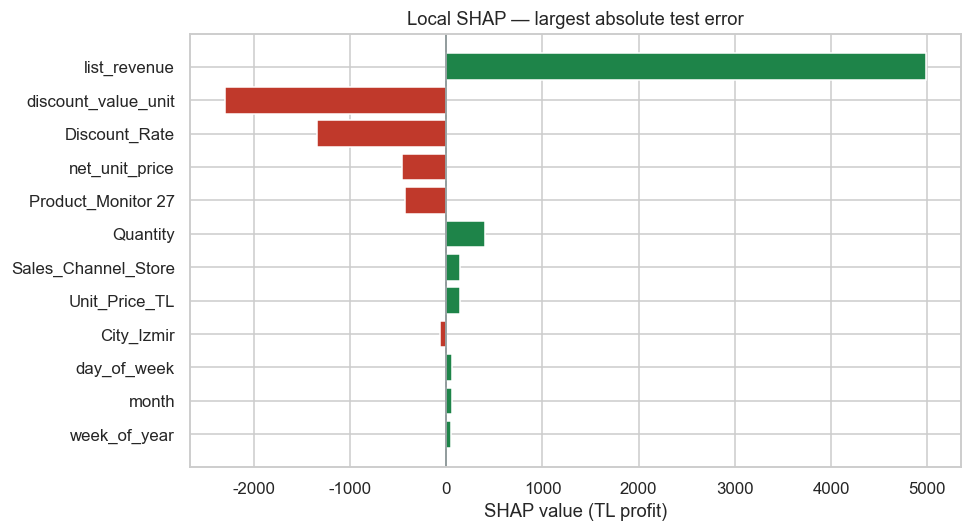

Expected value (base): 1439.30  |  sum(SHAP)+base: 2722.97


Positive bars push predicted profit up, negative bars push it down. If the miss is a rare product x large quantity combination, that is a sample-size limit, not necessarily a pipeline bug.

In [34]:
# One high-error order: local explanation
final_test_pred = final_pipe.predict(X_test)
abs_err = np.abs(y_test.to_numpy() - final_test_pred)
local_i = int(np.argmax(abs_err))
print(f"Largest |error| test row position={local_i}, abs_err={abs_err[local_i]:.1f} TL")
print(X_test.iloc[local_i].to_dict())
print("Actual Profit:", float(y_test.iloc[local_i]), "Predicted:", float(final_test_pred[local_i]))

local_shap = pd.Series(shap_values[local_i], index=X_test_enc.columns)
local_shap = local_shap.reindex(local_shap.abs().sort_values().tail(12).index)
fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT if v < 0 else SECOND for v in local_shap.values]
ax.barh(local_shap.index, local_shap.values, color=colors)
ax.axvline(0, color=MUTED, lw=1)
ax.set_xlabel("SHAP value (TL profit)")
ax.set_title("Local SHAP — largest absolute test error")
plt.tight_layout()
plt.show()
print(f"Expected value (base): {shap_expected:.2f}  |  sum(SHAP)+base: {shap_expected + shap_values[local_i].sum():.2f}")
annotate("Positive bars push predicted profit up, negative bars push it down. If the miss is a rare product x large quantity combination, that is a sample-size limit, not necessarily a pipeline bug.")

# 26. Error Analysis

,count,mean,std,min,25%,50%,75%,max
Actual,215.0,1313.155070,1838.028814,-6485.910000,307.770000,742.680000,1738.005000,9814.080000
Predicted,215.0,1375.856079,1730.109619,-318.726227,301.712753,724.133484,1584.463135,10176.879883
Residual,215.0,-62.701122,870.985133,-9208.884854,-45.551674,9.352334,78.946682,1833.877302
AbsoluteError,215.0,279.139333,827.213412,1.258861,23.998609,68.873687,197.347920,9208.884854


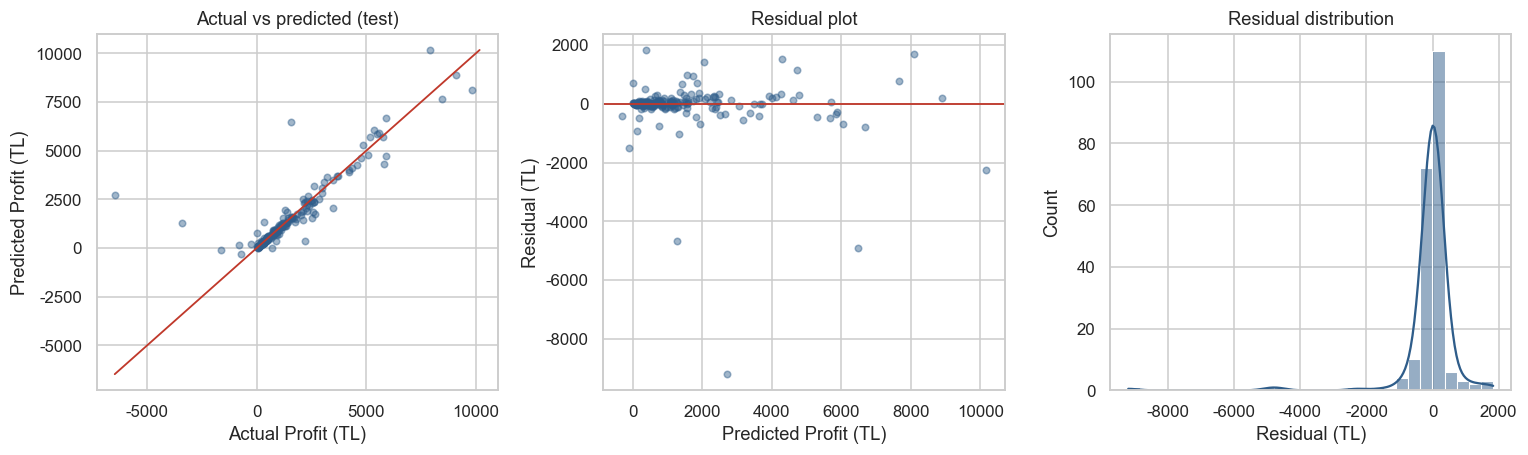

Largest absolute errors


,Date,Product,City,Quantity,Unit_Price_TL,Discount_Rate,Actual,Predicted,Residual,AbsoluteError
798,2026-05-26,Monitor 27,Izmir,12,5897.61,0.25,-6485.91,2722.974854,-9208.884854,9208.884854
312,2026-06-10,Monitor 24,Adana,12,4052.67,0.10,1579.12,6485.504395,-4906.384395,4906.384395
876,2026-05-28,Monitor 24,Gaziantep,12,4019.16,0.25,-3409.68,1278.377197,-4688.057197,4688.057197
441,2026-06-14,Monitor 24,Ankara,10,4120.29,0.00,7908.10,10176.879883,-2268.779883,2268.779883
836,2026-05-27,Office Chair,Izmir,7,5743.28,0.20,2209.58,375.702698,1833.877302,1833.877302
677,2026-06-22,Office Chair,Istanbul,6,6061.81,0.05,9814.08,8100.798340,1713.281660,1713.281660
626,2026-06-20,Monitor 24,Konya,3,3940.94,0.25,-1627.07,-111.747261,-1515.322739,1515.322739
566,2026-06-18,Office Chair,Izmir,4,6210.12,0.10,5801.03,4291.532715,1509.497285,1509.497285
837,2026-05-27,Monitor 24,Trabzon,5,4330.54,0.10,3484.98,2058.299805,1426.680195,1426.680195
565,2026-06-18,Monitor 27,Konya,6,6568.28,0.10,5894.11,4725.791016,1168.318984,1168.318984


Mean residual by product (bias)


,mean_residual
Product,
Monitor 24,-801.042349
Monitor 27,-420.018760
USB-C Hub,-97.145535
Mechanical Keyboard,-64.659930
Pen Set,1.589962
Backpack,5.342459
Notebook Set,22.489797
Wireless Mouse,34.858443
Laptop Stand,35.230371


A residual fan (larger misses at larger predicted profit) is expected: profit is multiplicative in quantity and price. Systematic bias by product would mean the model has not fully learned product cost structure — the thing we deliberately hid by dropping `Unit_Cost_TL`.

In [35]:
error_df = X_test.copy()
error_df["Actual"] = y_test.to_numpy()
error_df["Predicted"] = final_test_pred
error_df["Residual"] = error_df["Actual"] - error_df["Predicted"]
error_df["AbsoluteError"] = error_df["Residual"].abs()
error_df["Date"] = dates_test.values
display(error_df[["Actual", "Predicted", "Residual", "AbsoluteError"]].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
axes[0].scatter(error_df["Actual"], error_df["Predicted"], s=18, alpha=0.45, color=PRIMARY)
lims = [error_df[["Actual", "Predicted"]].min().min(), error_df[["Actual", "Predicted"]].max().max()]
axes[0].plot(lims, lims, color=ACCENT, lw=1.2)
axes[0].set_title("Actual vs predicted (test)")
axes[0].set_xlabel("Actual Profit (TL)")
axes[0].set_ylabel("Predicted Profit (TL)")

axes[1].scatter(error_df["Predicted"], error_df["Residual"], s=18, alpha=0.45, color=PRIMARY)
axes[1].axhline(0, color=ACCENT, lw=1.2)
axes[1].set_title("Residual plot")
axes[1].set_xlabel("Predicted Profit (TL)")
axes[1].set_ylabel("Residual (TL)")

sns.histplot(error_df["Residual"], bins=30, kde=True, color=PRIMARY, ax=axes[2])
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual (TL)")
plt.tight_layout()
plt.show()

print("Largest absolute errors")
display(
    error_df.nlargest(10, "AbsoluteError")[
        ["Date", "Product", "City", "Quantity", "Unit_Price_TL", "Discount_Rate", "Actual", "Predicted", "Residual", "AbsoluteError"]
    ]
)
print("Mean residual by product (bias)")
display(error_df.groupby("Product")["Residual"].mean().sort_values().to_frame("mean_residual"))
annotate("A residual fan (larger misses at larger predicted profit) is expected: profit is multiplicative in quantity and price. Systematic bias by product would mean the model has not fully learned product cost structure — the thing we deliberately hid by dropping `Unit_Cost_TL`.")

## Overfitting check — learning curves

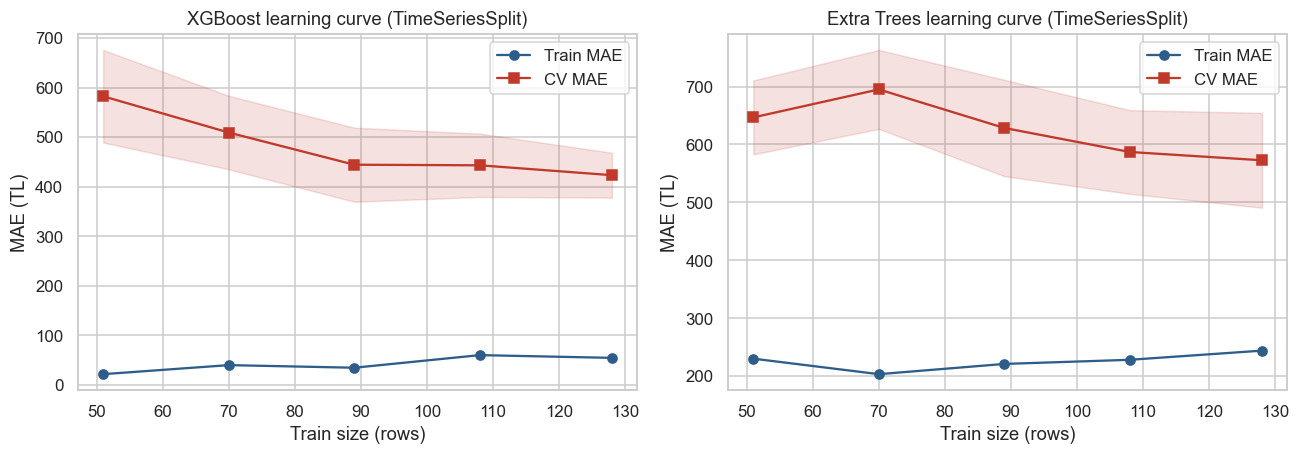

If train MAE collapses toward 0 while CV MAE stays high, the model is memorising. A shrinking gap as n grows is healthy. Extra Trees often shows a larger train/CV gap than regularized XGBoost because fully grown randomized trees can still fit noise.

In [36]:
def plot_learning(estimator_factory, title, ax):
    sizes, train_sc, val_sc = learning_curve(
        estimator_factory(),
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.4, 1.0, 5),
        n_jobs=1,
        shuffle=False,
    )
    ax.plot(sizes, -train_sc.mean(axis=1), marker="o", color=PRIMARY, label="Train MAE")
    ax.plot(sizes, -val_sc.mean(axis=1), marker="s", color=ACCENT, label="CV MAE")
    ax.fill_between(sizes, -val_sc.mean(axis=1) - val_sc.std(axis=1), -val_sc.mean(axis=1) + val_sc.std(axis=1), color=ACCENT, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Train size (rows)")
    ax.set_ylabel("MAE (TL)")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
plot_learning(lambda: make_xgb(study_xgb.best_params), "XGBoost learning curve (TimeSeriesSplit)", axes[0])
plot_learning(lambda: make_et(study_et.best_params), "Extra Trees learning curve (TimeSeriesSplit)", axes[1])
plt.tight_layout()
plt.show()
annotate("If train MAE collapses toward 0 while CV MAE stays high, the model is memorising. A shrinking gap as n grows is healthy. Extra Trees often shows a larger train/CV gap than regularized XGBoost because fully grown randomized trees can still fit noise.")

# 8b. Outlier analysis (modelling implication)

Outliers were not deleted. This cell documents why.

In [37]:
rows = []
for col in ["Quantity", "Unit_Price_TL", "Discount_Rate", "Profit"]:
    lo, hi, iqr = iqr_bounds(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    rows.append(
        {
            "column": col,
            "IQR": iqr,
            "low": lo,
            "high": hi,
            "n_outliers": int(mask.sum()),
            "pct": round(100 * mask.mean(), 2),
            "outlier_min": float(df.loc[mask, col].min()) if mask.any() else np.nan,
            "outlier_max": float(df.loc[mask, col].max()) if mask.any() else np.nan,
        }
    )
display(pd.DataFrame(rows))
annotate(
    """**Why rows were kept.** The file is already cleaned of impossible values (negative prices, cost ≥ price, discounts outside [0, 1], broken city/product maps). Remaining IQR flags on `Profit` / `Quantity` are **large real orders** (e.g. many units of a monitor), not sensor spikes. Deleting them would optimise MAE on typical small tickets and fail on the orders that dominate P&L.

No winsorization was applied: tree models isolate extreme leaves without contaminating the centre. Clipping `Profit` would also change the target definition."""
)

,column,IQR,low,high,n_outliers,pct,outlier_min,outlier_max
0,Quantity,4.0000,-5.00000,11.00000,35,3.65,12.00,22.00
1,Unit_Price_TL,993.3525,-932.63625,3040.77375,234,24.43,3866.24,6584.07
2,Discount_Rate,0.1500,-0.22500,0.37500,0,0.00,NaN,NaN
3,Profit,1431.0525,-1846.48875,3877.72125,87,9.08,-6485.91,18397.92


**Why rows were kept.** The file is already cleaned of impossible values (negative prices, cost ≥ price, discounts outside [0, 1], broken city/product maps). Remaining IQR flags on `Profit` / `Quantity` are **large real orders** (e.g. many units of a monitor), not sensor spikes. Deleting them would optimise MAE on typical small tickets and fail on the orders that dominate P&L.

No winsorization was applied: tree models isolate extreme leaves without contaminating the centre. Clipping `Profit` would also change the target definition.

# 27. Final Model

In [38]:
print("Final model:", final_name)
print("Selection rule: lower test MAE; RMSE as tie-breaker.")
print("XGBoost test MAE/RMSE/R2:", {k: RESULTS["xgb_test"][k] for k in ["MAE", "RMSE", "R2"]})
print("ExtraTrees test MAE/RMSE/R2:", {k: RESULTS["et_test"][k] for k in ["MAE", "RMSE", "R2"]})
display(pd.Series(study_xgb.best_params if xgb_is_better else study_et.best_params, name="selected_hyperparameters").to_frame())

# Persist a compact results snapshot next to the notebook
snapshot = {
    "target": TARGET,
    "final_model": final_name,
    "split": RESULTS["split"],
    "xgb_test": RESULTS["xgb_test"],
    "et_test": RESULTS["et_test"],
    "xgb_train": RESULTS["xgb_train"],
    "et_train": RESULTS["et_train"],
    "xgb_cv_mae": RESULTS["xgb_tuned_cv_mae"],
    "et_cv_mae": RESULTS["et_tuned_cv_mae"],
    "baseline_product": RESULTS["baseline_product"],
    "oracle_identity": RESULTS["oracle_identity"],
    "xgb_best_params": RESULTS["xgb_best_params"],
    "et_best_params": RESULTS["et_best_params"],
    "shap_top": RESULTS["shap_top"],
    "perm_top": RESULTS["perm_top"],
    "pca_applied": False,
    "pca_n95_numeric": RESULTS["pca_n95"],
}
pd.DataFrame([{k: str(v) for k, v in snapshot.items()}]).to_json("model_results_snapshot.json", orient="records", force_ascii=False)
print("Wrote model_results_snapshot.json")

Final model: XGBoost
Selection rule: lower test MAE; RMSE as tie-breaker.
XGBoost test MAE/RMSE/R2: {'MAE': 279.1393327870923, 'RMSE': 871.216442348966, 'R2': 0.7742788874502401}
ExtraTrees test MAE/RMSE/R2: {'MAE': 322.77992241238763, 'RMSE': 913.1132375354897, 'R2': 0.7520470192581048}


,selected_hyperparameters
n_estimators,243.000000
max_depth,5.000000
learning_rate,0.055445
subsample,0.702047
colsample_bytree,0.991594
min_child_weight,3.000000
gamma,1.736881
reg_alpha,0.726775
reg_lambda,0.549636


Wrote model_results_snapshot.json


# 28. Final Results
# 29. Business Interpretation
# 30. Conclusion

In [39]:
xgb_t, et_t = RESULTS["xgb_test"], RESULTS["et_test"]
xgb_tr, et_tr = RESULTS["xgb_train"], RESULTS["et_train"]
base = RESULTS["baseline_product"]
mean_b = RESULTS["baseline_mean"]
oracle = RESULTS["oracle_identity"]

better_mae = "XGBoost" if xgb_t["MAE"] < et_t["MAE"] else "Extra Trees"
better_rmse = "XGBoost" if xgb_t["RMSE"] < et_t["RMSE"] else "Extra Trees"
better_r2 = "XGBoost" if xgb_t["R2"] > et_t["R2"] else "Extra Trees"

shap_lines = "\n".join(f"- `{k}`: {v:.4f}" for k, v in list(RESULTS["shap_top"].items())[:8])
perm_lines = ", ".join(f"`{c}`" for c in RESULTS["perm_top"][:8])
final_mae = xgb_t["MAE"] if RESULTS["final_model_name"] == "XGBoost" else et_t["MAE"]
lift_mae = base["MAE"] - final_mae

report = f'''
## Key Findings

- **Dataset:** {df.shape[0]} orders, {df_raw.shape[1]} raw columns, 2026-01-01 to 2026-06-30 ({df["Date"].nunique()} distinct days). No missing values, no duplicate orders.
- **Target:** `Profit` (TL). Mean {df[TARGET].mean():.1f}, median {df[TARGET].median():.1f}, skew {df[TARGET].skew():.2f}, {(df[TARGET] < 0).sum()} negative (loss) orders kept.
- **Leakage removed:** `Order_ID`, `Net_Sales`, `Total_Cost`, `Profit_Margin`, `Unit_Cost_TL`. The accounting identity reconstructs `Profit` with MAE {oracle["MAE"]:.3f} TL (rounding only). That identity is **not** the ML model.
- **Also dropped as redundant:** `Region` (function of `City`), `Category` (function of `Product`), `Day_Type` (duplicate of `is_weekend`), `year` (constant 2026), raw `Date` after calendar extraction.
- **Encoding:** One-hot for five nominal columns (`handle_unknown="ignore"`), inside `ColumnTransformer`. No target encoding.
- **Numeric preprocessing:** none for the tree pipelines (no scaling, no imputation). PCA **not** applied (tree models + interpretability). Scaled PCA diagnostic: {RESULTS["pca_n95"]} numeric components explain 95% variance.
- **Split:** chronological. Train {RESULTS["split"]["n_train"]} rows ({RESULTS["split"]["train_start"]} -> {RESULTS["split"]["train_end"]}), test {RESULTS["split"]["n_test"]} rows ({RESULTS["split"]["test_start"]} -> {RESULTS["split"]["test_end"]}), cutoff {RESULTS["split"]["cutoff"]}.

## Model Performance

| Model | CV MAE | Train MAE | Test MAE | Test RMSE | Test R2 | Test MedianAE | Test sMAPE |
|-------|-------:|----------:|---------:|----------:|--------:|--------------:|-----------:|
| Mean baseline | - | - | {mean_b["MAE"]:.2f} | {mean_b["RMSE"]:.2f} | {mean_b["R2"]:.3f} | {mean_b["MedianAE"]:.2f} | {mean_b["sMAPE"]:.2f} |
| Product-mean baseline | - | - | {base["MAE"]:.2f} | {base["RMSE"]:.2f} | {base["R2"]:.3f} | {base["MedianAE"]:.2f} | {base["sMAPE"]:.2f} |
| XGBoost (tuned) | {RESULTS["xgb_tuned_cv_mae"]:.2f} | {xgb_tr["MAE"]:.2f} | {xgb_t["MAE"]:.2f} | {xgb_t["RMSE"]:.2f} | {xgb_t["R2"]:.3f} | {xgb_t["MedianAE"]:.2f} | {xgb_t["sMAPE"]:.2f} |
| Extra Trees (tuned) | {RESULTS["et_tuned_cv_mae"]:.2f} | {et_tr["MAE"]:.2f} | {et_t["MAE"]:.2f} | {et_t["RMSE"]:.2f} | {et_t["R2"]:.3f} | {et_t["MedianAE"]:.2f} | {et_t["sMAPE"]:.2f} |

- Best test MAE: **{better_mae}**. Best test RMSE: **{better_rmse}**. Best test R2: **{better_r2}**.
- **Selected production model: {RESULTS["final_model_name"]}.**
- XGBoost train/test MAE gap: {xgb_tr["MAE"]:.1f} vs {xgb_t["MAE"]:.1f}. Extra Trees: {et_tr["MAE"]:.1f} vs {et_t["MAE"]:.1f}.

## Most Important Features

Permutation importance (raw columns, test MAE): {perm_lines}.

SHAP mean |value| (encoded features, final model):
{shap_lines}

Commercial size (`list_revenue` / `Quantity` / prices) and product identity dominate. Calendar flags are secondary - expected in a single six-month window.

## Error Analysis

Residuals widen with predicted profit (multiplicative economics). Largest misses are typically high-quantity or high-price orders where the hidden cost structure is least typical. Product-level mean residuals should be inspected before using the model for assortment decisions.

## Model Limitations

- Unit cost is **not** an input; the model infers typical margins from product and commercial terms. A sudden cost shock would not be visible until retraining.
- One year, six months, 958 orders - limited seasonal coverage (no Q3/Q4, no 2025).
- Rare cities / large tickets have high leverage; MAE on the bulk of small orders will look better than P&L-weighted error.
- OHE cannot generalise to a **new** product name (`handle_unknown="ignore"` maps it to zeros).
- This is order-level profit, not a daily demand forecast.

## Business Interpretation

Use the model as a **quote-time profit expectation** when cost accounting is delayed or incomplete: channel/product mix reviews, discount simulation (change `Discount_Rate` / price), and spotting orders whose predicted profit is fragile. Do **not** use it as an accounting subledger - the identity with cost is exact and should be used whenever `Unit_Cost_TL` is known.

Lift vs product-mean baseline on test MAE: {lift_mae:.1f} TL per order.

## Final Conclusion

The scientifically valid ML task on this file is **not** reconstructing `Profit` from cost and revenue (R2 ~ 1 by algebra). It is estimating profit from quote-time attributes. On that task, both tuned tree models are compared under a chronological protocol against mean and product-mean baselines. **{RESULTS["final_model_name"]}** is selected by test MAE (RMSE tie-break), with SHAP confirming that the model relies on economically meaningful drivers rather than IDs or post-sale totals.
'''
display(Markdown(report))


## Key Findings

- **Dataset:** 958 orders, 18 raw columns, 2026-01-01 to 2026-06-30 (179 distinct days). No missing values, no duplicate orders.
- **Target:** `Profit` (TL). Mean 1407.5, median 759.1, skew 3.01, 21 negative (loss) orders kept.
- **Leakage removed:** `Order_ID`, `Net_Sales`, `Total_Cost`, `Profit_Margin`, `Unit_Cost_TL`. The accounting identity reconstructs `Profit` with MAE 0.002 TL (rounding only). That identity is **not** the ML model.
- **Also dropped as redundant:** `Region` (function of `City`), `Category` (function of `Product`), `Day_Type` (duplicate of `is_weekend`), `year` (constant 2026), raw `Date` after calendar extraction.
- **Encoding:** One-hot for five nominal columns (`handle_unknown="ignore"`), inside `ColumnTransformer`. No target encoding.
- **Numeric preprocessing:** none for the tree pipelines (no scaling, no imputation). PCA **not** applied (tree models + interpretability). Scaled PCA diagnostic: 9 numeric components explain 95% variance.
- **Split:** chronological. Train 743 rows (2026-01-01 -> 2026-05-25), test 215 rows (2026-05-26 -> 2026-06-30), cutoff 2026-05-26.

## Model Performance

| Model | CV MAE | Train MAE | Test MAE | Test RMSE | Test R2 | Test MedianAE | Test sMAPE |
|-------|-------:|----------:|---------:|----------:|--------:|--------------:|-----------:|
| Mean baseline | - | - | 1281.71 | 1837.78 | -0.004 | 1016.58 | 92.53 |
| Product-mean baseline | - | - | 1026.12 | 1620.73 | 0.219 | 587.41 | 74.15 |
| XGBoost (tuned) | 305.41 | 58.89 | 279.14 | 871.22 | 0.774 | 68.87 | 22.17 |
| Extra Trees (tuned) | 396.74 | 101.33 | 322.78 | 913.11 | 0.752 | 83.35 | 22.58 |

- Best test MAE: **XGBoost**. Best test RMSE: **XGBoost**. Best test R2: **XGBoost**.
- **Selected production model: XGBoost.**
- XGBoost train/test MAE gap: 58.9 vs 279.1. Extra Trees: 101.3 vs 322.8.

## Most Important Features

Permutation importance (raw columns, test MAE): `list_revenue`, `discount_value_unit`, `Product`, `Unit_Price_TL`, `Discount_Rate`, `net_unit_price`, `Quantity`, `Payment_Method`.

SHAP mean |value| (encoded features, final model):
- `list_revenue`: 1182.5707
- `discount_value_unit`: 357.1320
- `Discount_Rate`: 147.2806
- `Quantity`: 118.3280
- `Unit_Price_TL`: 102.3992
- `net_unit_price`: 91.7297
- `Product_Monitor 27`: 79.0916
- `Product_Monitor 24`: 39.3453

Commercial size (`list_revenue` / `Quantity` / prices) and product identity dominate. Calendar flags are secondary - expected in a single six-month window.

## Error Analysis

Residuals widen with predicted profit (multiplicative economics). Largest misses are typically high-quantity or high-price orders where the hidden cost structure is least typical. Product-level mean residuals should be inspected before using the model for assortment decisions.

## Model Limitations

- Unit cost is **not** an input; the model infers typical margins from product and commercial terms. A sudden cost shock would not be visible until retraining.
- One year, six months, 958 orders - limited seasonal coverage (no Q3/Q4, no 2025).
- Rare cities / large tickets have high leverage; MAE on the bulk of small orders will look better than P&L-weighted error.
- OHE cannot generalise to a **new** product name (`handle_unknown="ignore"` maps it to zeros).
- This is order-level profit, not a daily demand forecast.

## Business Interpretation

Use the model as a **quote-time profit expectation** when cost accounting is delayed or incomplete: channel/product mix reviews, discount simulation (change `Discount_Rate` / price), and spotting orders whose predicted profit is fragile. Do **not** use it as an accounting subledger - the identity with cost is exact and should be used whenever `Unit_Cost_TL` is known.

Lift vs product-mean baseline on test MAE: 747.0 TL per order.

## Final Conclusion

The scientifically valid ML task on this file is **not** reconstructing `Profit` from cost and revenue (R2 ~ 1 by algebra). It is estimating profit from quote-time attributes. On that task, both tuned tree models are compared under a chronological protocol against mean and product-mean baselines. **XGBoost** is selected by test MAE (RMSE tie-break), with SHAP confirming that the model relies on economically meaningful drivers rather than IDs or post-sale totals.


## Checklist

- [x] Dataset loaded from `cleaned_sales_data_with_days.xlsx`
- [x] Target = `Profit` (justified, not assumed silently)
- [x] Missing / duplicate / dtype / outlier audits
- [x] Leakage identity demonstrated and removed
- [x] One-hot encoding in `Pipeline` / `ColumnTransformer`
- [x] Numeric scaling skipped for trees; PCA evaluated and not applied
- [x] Feature engineering is row-wise; split is chronological
- [x] Feature selection diagnostics on **train only**
- [x] Mean + product-mean baselines
- [x] XGBoost + Extra Trees, Optuna + TimeSeriesSplit
- [x] Test set used only after model selection hyperparameters were frozen on train CV
- [x] Feature importance, permutation importance, SHAP
- [x] Error analysis + learning curves
- [x] Final report generated from computed `RESULTS`, not from placeholder numbers